# Credit Card Fraud Detection — Data Understanding and Exploratory Data Analysis

## Notebook 1: Data Understanding and EDA

This notebook is the first stage of a full end-to-end fraud detection pipeline. Its purpose is to understand the structure of the dataset, assess data quality, and uncover the behavioral patterns that distinguish fraudulent from legitimate transactions.

The analysis in this notebook lays the foundation for all later stages of the project, including:

- SQL analytics
- feature engineering
- machine learning
- model optimization
- explainability
- Double Machine Learning

---

## Objectives

The goals of this notebook are to:

1. understand the structure and quality of the training and testing datasets
2. assess the fraud target distribution and the level of class imbalance
3. analyze transaction behavior across amount, time, location, customer, and merchant dimensions
4. identify patterns across demographic variables such as age and gender
5. understand how fraud varies across category, state, city, merchant, and job
6. generate insights that will guide SQL analysis, feature engineering, and model design

---

## Why this stage matters

Fraud detection is not only a modeling problem. It is first a behavioral problem.

Before any model is trained, it is necessary to understand:

- how rare fraud is
- which transaction types are most exposed
- whether fraud clusters in specific times or places
- whether certain customer behaviors are systematically different
- which variables are likely to be valuable in later modeling stages

This notebook answers those questions at a descriptive level.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
OCEAN_PALETTE = [
    "#DFF3F0",
    "#BFEAE5",
    "#79D0D3",
    "#3E9FBF",
    "#1F6F8B",
    "#174A7E",
    "#0F2F5F",
    "#081F3F",
    "#04162E"
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

---
## 1. Load the Training and Testing Datasets

The project uses predefined training and testing datasets. In this notebook, both datasets are loaded and then combined for exploratory analysis. This is appropriate because EDA is descriptive rather than predictive.

Using the full data allows for a more complete view of fraud patterns across the entire available transaction history.

In [3]:
TRAIN_PATH = "/kaggle/input/datasets/kaushalnandania/credit-card-fraud-detection/train.csv"
TEST_PATH = "/kaggle/input/datasets/kaushalnandania/credit-card-fraud-detection/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1296675, 23)
Test shape: (555719, 23)


In [4]:
display(train_df.head())
display(test_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.8600,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.9864,-81.2007,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.8400,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.4505,-109.9604,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.2800,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.4958,-74.1961,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.0500,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.8124,-80.8831,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.1900,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.9591,-85.8847,0


In [5]:
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print("Combined shape:", df.shape)

Combined shape: (1852394, 23)


---
## 2. Dataset Overview

This section introduces the overall structure of the data, including the number of rows and columns, data types, and broad variable categories.

The dataset contains transaction-level observations with information about:

- transaction time and amount
- customer identity and demographics
- merchant and category
- customer and merchant geography
- fraud target label

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1852394
Number of columns: 23


In [7]:
overview_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().sum().values / len(df)) * 100
})

display(overview_df.sort_values("missing_count", ascending=False))

,column,dtype,missing_count,missing_pct
0,Unnamed: 0,int64,0,0.0000
1,trans_date_trans_time,object,0,0.0000
2,cc_num,int64,0,0.0000
3,merchant,object,0,0.0000
4,category,object,0,0.0000
5,amt,float64,0,0.0000
6,first,object,0,0.0000
7,last,object,0,0.0000
8,gender,object,0,0.0000
9,street,object,0,0.0000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud          

---
## 3. Basic Cleaning and Type Standardization

Before analysis begins, the dataset is lightly cleaned to ensure consistency.

The main steps are:

- remove any index-like unnamed columns if present
- convert transaction date and birth date into datetime format
- standardize string columns

In [9]:
drop_cols = [col for col in df.columns if "unnamed" in col.lower()]
if drop_cols:
    df = df.drop(columns=drop_cols)

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

string_cols = df.select_dtypes(include="object").columns.tolist()
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1852394, 22)


---
## 4. Data Quality Assessment

This section checks for:

- missing values
- duplicate records
- duplicate transaction identifiers

These checks are important because data quality issues can distort fraud patterns and lead to misleading interpretations.

In [10]:
missing_summary = (
    df.isna()
      .sum()
      .reset_index()
      .rename(columns={"index": "column", 0: "missing_count"})
)

missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df)) * 100
display(missing_summary.sort_values("missing_count", ascending=False))

,column,missing_count,missing_pct
0,trans_date_trans_time,0,0.0000
1,cc_num,0,0.0000
2,merchant,0,0.0000
3,category,0,0.0000
4,amt,0,0.0000
5,first,0,0.0000
6,last,0,0.0000
7,gender,0,0.0000
8,street,0,0.0000
9,city,0,0.0000


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
if "trans_num" in df.columns:
    print("Duplicate transaction IDs:", df["trans_num"].duplicated().sum())

Duplicate transaction IDs: 0


---
## 5. Date and Time Preparation

Time is often one of the strongest contextual variables in fraud detection. To analyze temporal patterns, the transaction timestamp is decomposed into multiple interpretable components.

In [13]:
df["trans_hour"] = df["trans_date_trans_time"].dt.hour
df["trans_day"] = df["trans_date_trans_time"].dt.day
df["trans_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
df["trans_month"] = df["trans_date_trans_time"].dt.month
df["trans_year"] = df["trans_date_trans_time"].dt.year
df["trans_date"] = df["trans_date_trans_time"].dt.date

df["is_weekend"] = df["trans_dayofweek"].isin([5, 6]).astype(int)
df["is_night_transaction"] = ((df["trans_hour"] >= 22) | (df["trans_hour"] <= 3)).astype(int)

day_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}
df["trans_day_name"] = df["trans_dayofweek"].map(day_map)

display(df[[
    "trans_date_trans_time",
    "trans_hour",
    "trans_dayofweek",
    "trans_day_name",
    "trans_month",
    "is_weekend",
    "is_night_transaction"
]].head())

,trans_date_trans_time,trans_hour,trans_dayofweek,trans_day_name,trans_month,is_weekend,is_night_transaction
0,2019-01-01 00:00:18,0,1,Tuesday,1,0,1
1,2019-01-01 00:00:44,0,1,Tuesday,1,0,1
2,2019-01-01 00:00:51,0,1,Tuesday,1,0,1
3,2019-01-01 00:01:16,0,1,Tuesday,1,0,1
4,2019-01-01 00:03:06,0,1,Tuesday,1,0,1


---
## 6. Customer Age Preparation

Age is included as a demographic context variable. It can help reveal whether fraud patterns vary across life stages, even if age itself is not a direct causal driver.

In [14]:
df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(float)
df["age"] = df["age"].clip(lower=0)

df["age_band"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)

display(df[["dob", "age", "age_band"]].head())

,dob,age,age_band
0,1988-03-09,30.8145,25-34
1,1978-06-21,40.5311,35-44
2,1962-01-19,56.9500,55-64
3,1967-01-12,51.9699,45-54
4,1986-03-28,32.7639,25-34


---
## 7. Target Variable Analysis

This section examines the class distribution of the fraud target. The main objective is to quantify the severity of the fraud imbalance problem.

In [15]:
target_summary = (
    df["is_fraud"]
    .value_counts()
    .rename_axis("is_fraud")
    .reset_index(name="count")
)

target_summary["percentage"] = target_summary["count"] / len(df) * 100
display(target_summary)

,is_fraud,count,percentage
0,0,1842743,99.4790
1,1,9651,0.5210


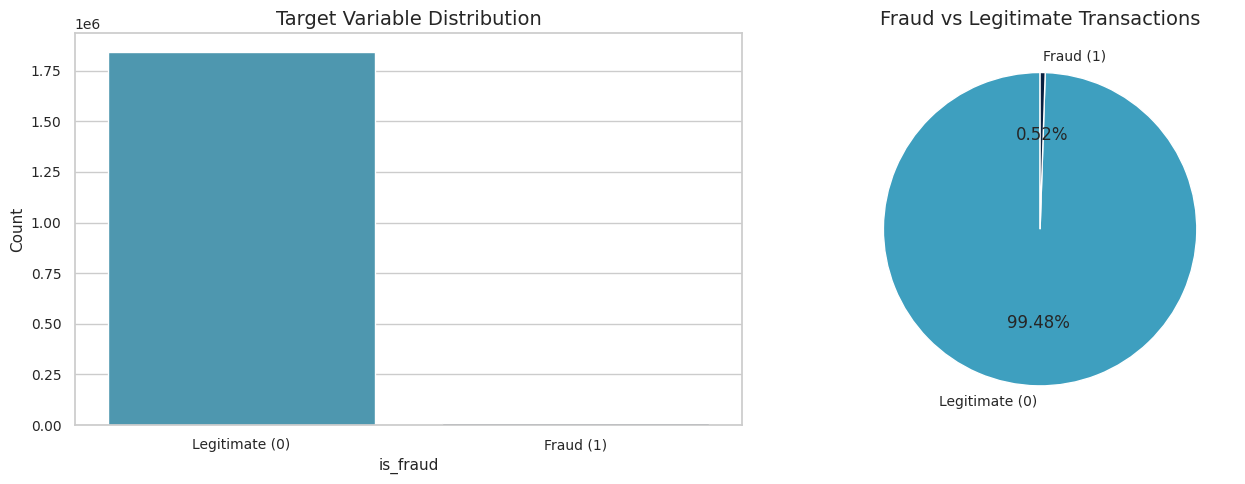

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=target_summary,
    x="is_fraud",
    y="count",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[7]],
    ax=axes[0]
)
axes[0].set_title("Target Variable Distribution")
axes[0].set_xlabel("is_fraud")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"])

axes[1].pie(
    target_summary["count"],
    labels=["Legitimate (0)", "Fraud (1)"],
    autopct="%1.2f%%",
    startangle=90,
    colors=[OCEAN_PALETTE[3], OCEAN_PALETTE[7]],
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
axes[1].set_title("Fraud vs Legitimate Transactions")

plt.tight_layout()
plt.show()

---
## 8. Numerical Variable Summary

This section provides a broad statistical view of the main numerical variables before deeper comparisons are made.

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
cc_num,"1,852,394.0000","417,386,038,393,710,400.0000","1,309,115,265,318,020,352.0000","60,416,207,185.0000","180,042,946,491,150.0000","3,521,417,320,836,166.0000","4,642,255,475,285,942.0000","4,992,346,398,065,154,048.0000"
amt,"1,852,394.0000",70.0636,159.2540,1.0000,9.6400,47.4500,83.1000,"28,948.9000"
zip,"1,852,394.0000","48,813.2582","26,881.8460","1,257.0000","26,237.0000","48,174.0000","72,042.0000","99,921.0000"
lat,"1,852,394.0000",38.5393,5.0715,20.0271,34.6689,39.3543,41.9404,66.6933
long,"1,852,394.0000",-90.2278,13.7479,-165.6723,-96.7980,-87.4769,-80.1580,-67.9503
city_pop,"1,852,394.0000","88,643.6745","301,487.6183",23.0000,741.0000,"2,443.0000","20,328.0000","2,906,700.0000"
unix_time,"1,852,394.0000","1,358,674,218.8344","18,195,081.3876","1,325,376,018.0000","1,343,016,823.7500","1,357,089,331.0000","1,374,581,485.2500","1,388,534,374.0000"
merch_lat,"1,852,394.0000",38.5390,5.1056,19.0274,34.7401,39.3689,41.9563,67.5103
merch_long,"1,852,394.0000",-90.2279,13.7597,-166.6716,-96.8994,-87.4407,-80.2451,-66.9509
is_fraud,"1,852,394.0000",0.0052,0.0720,0.0000,0.0000,0.0000,0.0000,1.0000


---
## 9. Core Distribution Analysis

This section examines the raw distribution of transaction amount, city population, and customer age.

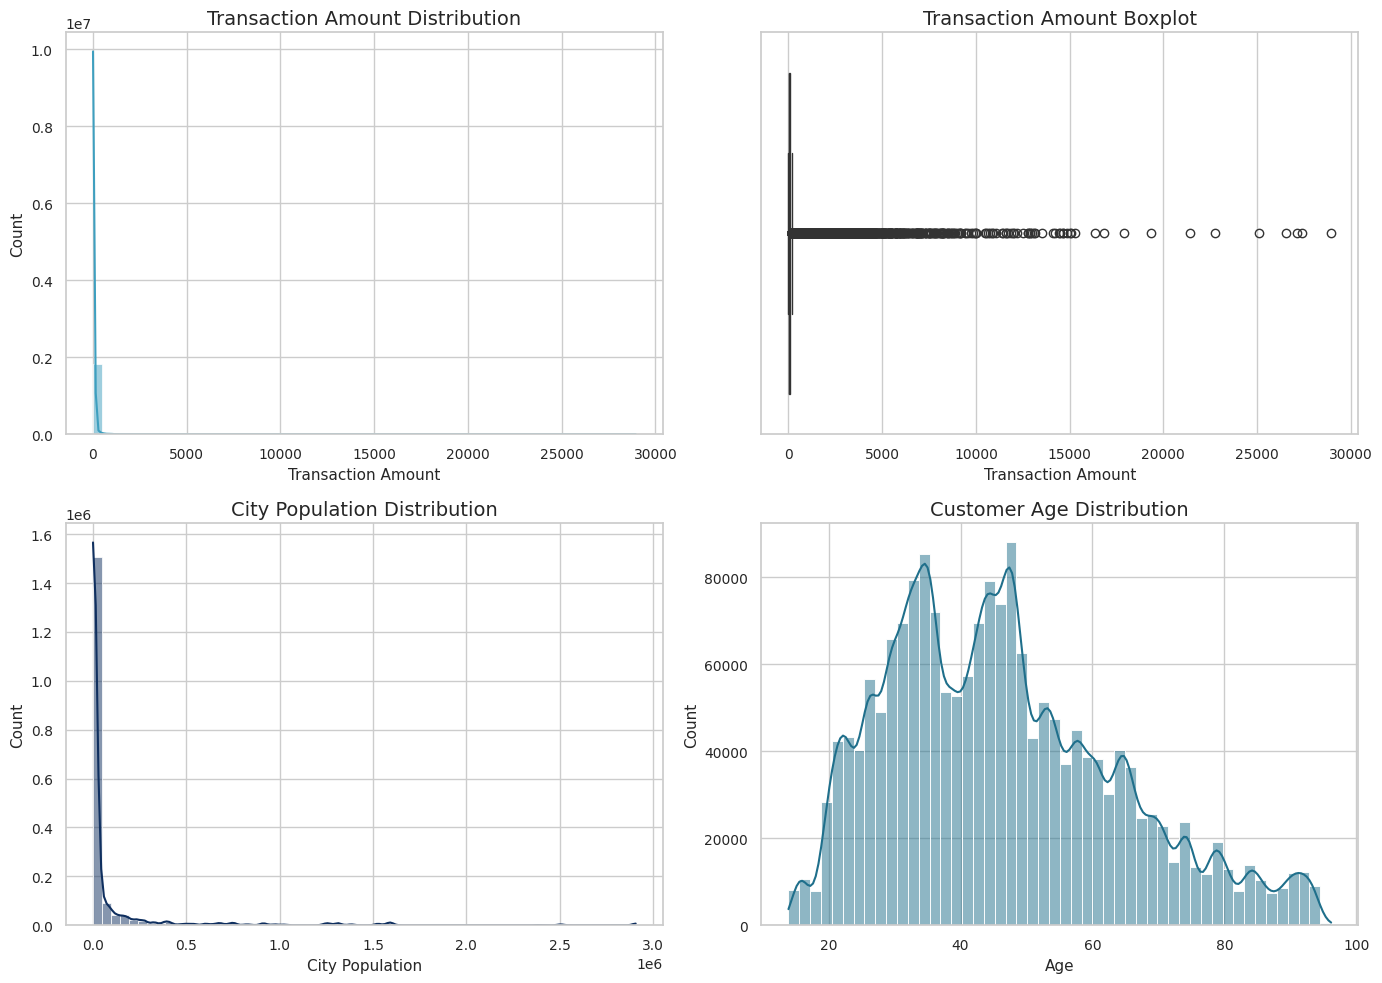

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(
    df["amt"],
    bins=60,
    kde=True,
    color=OCEAN_PALETTE[3],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Transaction Amount Distribution")
axes[0, 0].set_xlabel("Transaction Amount")
axes[0, 0].set_ylabel("Count")

sns.boxplot(
    x=df["amt"],
    color=OCEAN_PALETTE[4],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Transaction Amount Boxplot")
axes[0, 1].set_xlabel("Transaction Amount")

sns.histplot(
    df["city_pop"],
    bins=60,
    kde=True,
    color=OCEAN_PALETTE[6],
    ax=axes[1, 0]
)
axes[1, 0].set_title("City Population Distribution")
axes[1, 0].set_xlabel("City Population")
axes[1, 0].set_ylabel("Count")

sns.histplot(
    df["age"].dropna(),
    bins=50,
    kde=True,
    color=OCEAN_PALETTE[4],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Customer Age Distribution")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## 10. Raw and Log-Transformed Amount

Because transaction amount is heavily skewed, a log transformation is useful for later modeling and interpretation.

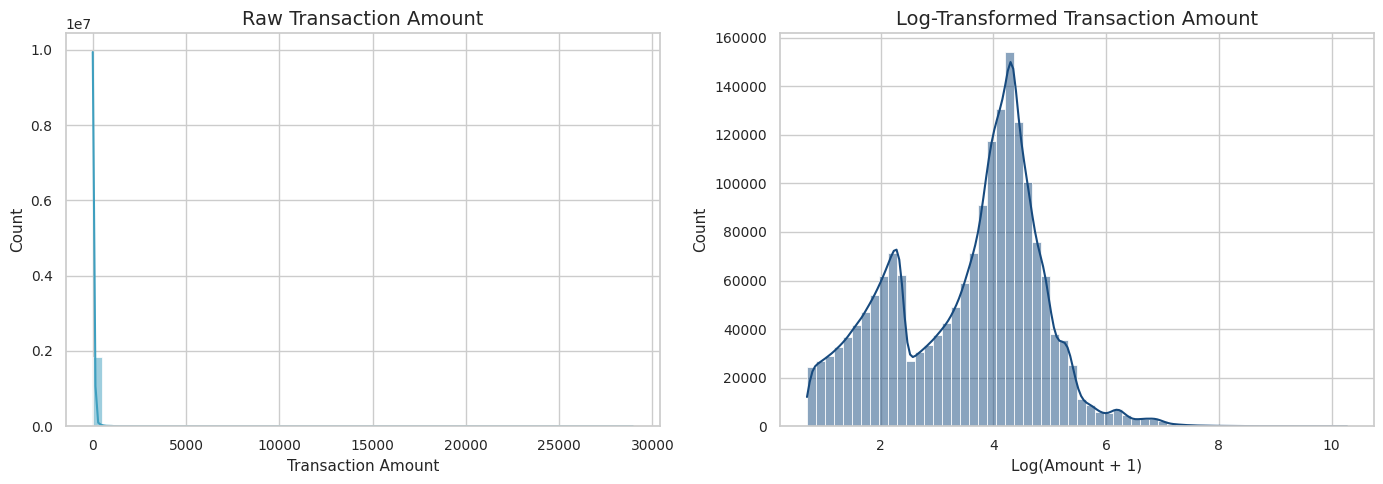

In [19]:
df["log_amt"] = np.log1p(df["amt"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["amt"],
    bins=60,
    kde=True,
    color=OCEAN_PALETTE[3],
    ax=axes[0]
)
axes[0].set_title("Raw Transaction Amount")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Count")

sns.histplot(
    df["log_amt"],
    bins=60,
    kde=True,
    color=OCEAN_PALETTE[5],
    ax=axes[1]
)
axes[1].set_title("Log-Transformed Transaction Amount")
axes[1].set_xlabel("Log(Amount + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## 11. Categorical Variable Overview

This section identifies the main categorical fields and their cardinality. It helps distinguish between lower-cardinality variables that are easy to summarize and high-cardinality variables that may require aggregation later.

In [20]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

cardinality_df = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[col].nunique() for col in categorical_cols]
}).sort_values("unique_values", ascending=False)

display(cardinality_df)

,column,unique_values
9,trans_num,1852394
5,street,999
6,city,906
10,trans_date,730
0,merchant,693
8,job,497
3,last,486
2,first,355
7,state,51
1,category,14


---
## 12. Gender Analysis

Gender is examined here as a contextual demographic variable. The purpose is descriptive rather than causal.

In [21]:
gender_counts = (
    df["gender"]
    .value_counts()
    .rename_axis("gender")
    .reset_index(name="count")
)

gender_fraud = (
    df.groupby("gender")["is_fraud"]
    .agg(count="count", fraud_cases="sum", fraud_rate="mean")
    .reset_index()
)

gender_fraud["fraud_rate_pct"] = gender_fraud["fraud_rate"] * 100

display(gender_counts)
display(gender_fraud)

,gender,count
0,F,1014749
1,M,837645


,gender,count,fraud_cases,fraud_rate,fraud_rate_pct
0,F,1014749,4899,0.0048,0.4828
1,M,837645,4752,0.0057,0.5673


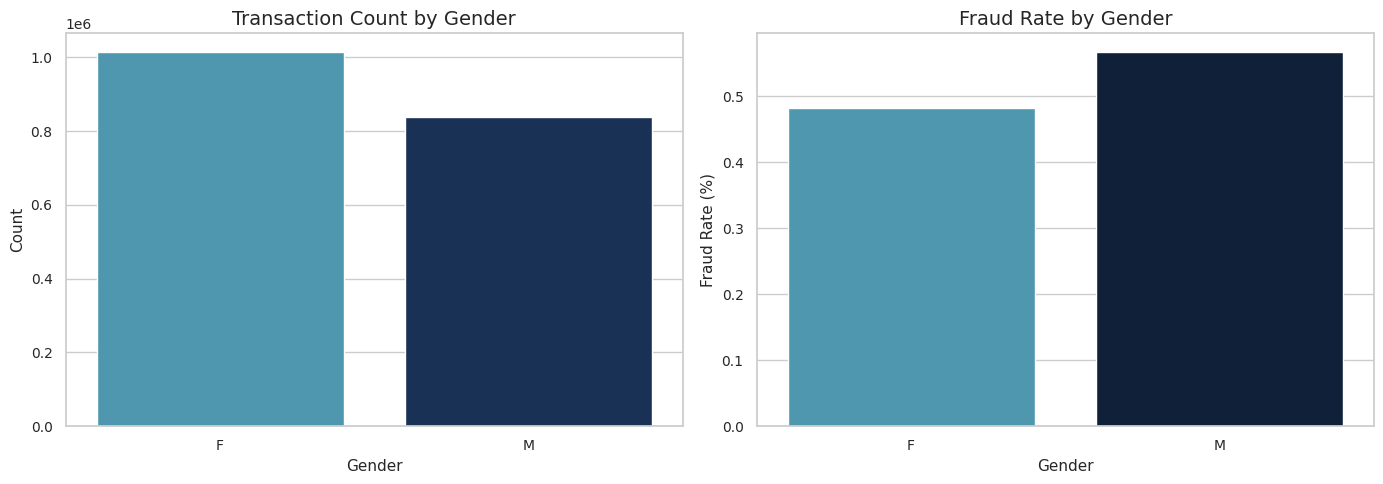

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=gender_counts,
    x="gender",
    y="count",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[6]],
    ax=axes[0]
)
axes[0].set_title("Transaction Count by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

sns.barplot(
    data=gender_fraud,
    x="gender",
    y="fraud_rate_pct",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[7]],
    ax=axes[1]
)
axes[1].set_title("Fraud Rate by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

#### Insight

Gender-level differences should be interpreted carefully. Fraud rates differ across gender groups, that does not imply gender itself causes fraud. More often, such differences reflect interactions with category, merchant exposure, time-of-day behavior, or transaction size. Gender is therefore best understood as contextual rather than deterministic.

---
## 13. Age Analysis

This section examines age from multiple angles:

- age distribution
- transaction count by age band
- fraud rate by age band
- smoothed fraud rate by exact age

In [23]:
age_band_summary = (
    df.groupby("age_band", observed=False)["is_fraud"]
    .agg(count="count", fraud_cases="sum", fraud_rate="mean")
    .reset_index()
)
age_band_summary["fraud_rate_pct"] = age_band_summary["fraud_rate"] * 100

age_exact_summary = (
    df.dropna(subset=["age"])
      .groupby(df["age"].astype(int))["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
      .rename(columns={"age": "age_year"})
)

age_exact_summary["fraud_rate_pct"] = age_exact_summary["fraud_rate"] * 100
age_exact_summary["fraud_rate_smooth"] = (
    age_exact_summary["fraud_rate_pct"]
    .rolling(window=5, center=True, min_periods=1)
    .mean()
)

display(age_band_summary)
display(age_exact_summary.head(10))

,age_band,count,fraud_cases,fraud_rate,fraud_rate_pct
0,Under 25,168055,917,0.0055,0.5457
1,25-34,401345,1818,0.0045,0.4530
2,35-44,392861,1549,0.0039,0.3943
3,45-54,372788,1918,0.0051,0.5145
4,55-64,232661,1596,0.0069,0.6860
5,65+,284684,1853,0.0065,0.6509


,age_year,count,fraud_cases,fraud_rate,fraud_rate_pct,fraud_rate_smooth
0,13,81,0,0.0000,0.0000,0.2117
1,14,3944,12,0.0030,0.3043,0.2500
2,15,8159,27,0.0033,0.3309,0.4961
3,16,5759,21,0.0036,0.3646,0.5964
4,17,3917,58,0.0148,1.4807,0.6439
5,18,6181,31,0.0050,0.5015,0.6733
6,19,15873,86,0.0054,0.5418,0.7341
7,20,22612,108,0.0048,0.4776,0.5392
8,21,26620,178,0.0067,0.6687,0.5641
9,22,28839,146,0.0051,0.5063,0.5474


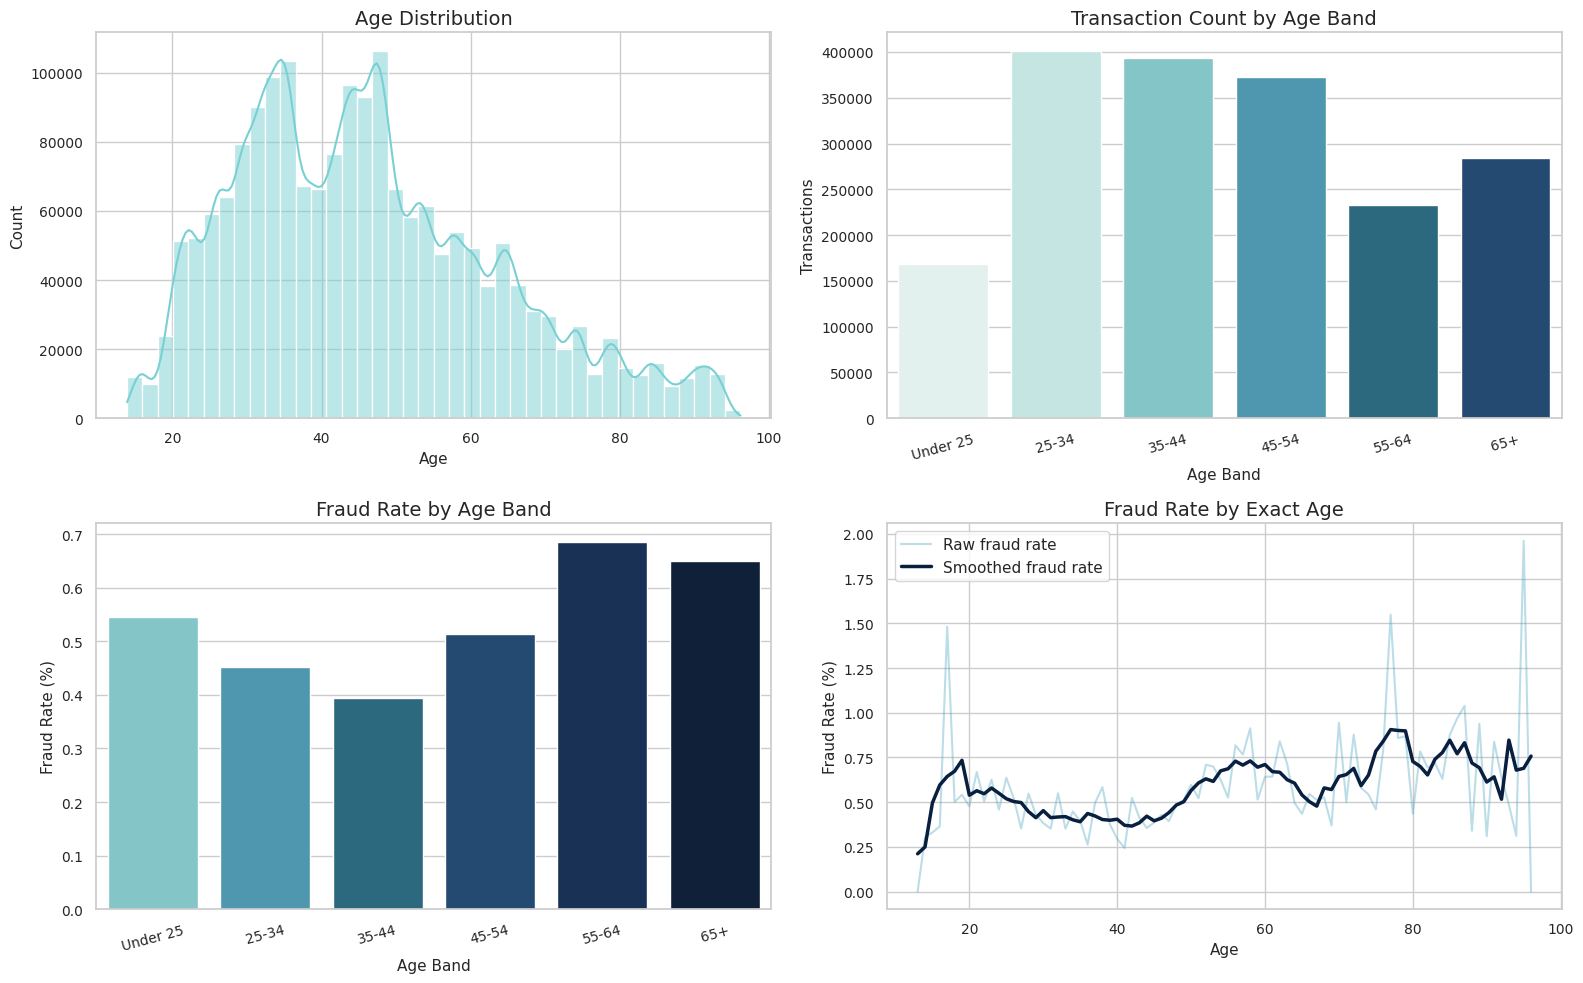

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(
    df["age"].dropna(),
    bins=40,
    kde=True,
    color=OCEAN_PALETTE[2],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

sns.barplot(
    data=age_band_summary,
    x="age_band",
    y="count",
    palette=OCEAN_PALETTE[:6],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Transaction Count by Age Band")
axes[0, 1].set_xlabel("Age Band")
axes[0, 1].set_ylabel("Transactions")
axes[0, 1].tick_params(axis="x", rotation=15)

sns.barplot(
    data=age_band_summary,
    x="age_band",
    y="fraud_rate_pct",
    palette=OCEAN_PALETTE[2:8],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Fraud Rate by Age Band")
axes[1, 0].set_xlabel("Age Band")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=15)

axes[1, 1].plot(
    age_exact_summary["age_year"],
    age_exact_summary["fraud_rate_pct"],
    color=OCEAN_PALETTE[3],
    alpha=0.35,
    linewidth=1.5,
    label="Raw fraud rate"
)
axes[1, 1].plot(
    age_exact_summary["age_year"],
    age_exact_summary["fraud_rate_smooth"],
    color=OCEAN_PALETTE[7],
    linewidth=2.5,
    label="Smoothed fraud rate"
)
axes[1, 1].set_title("Fraud Rate by Exact Age")
axes[1, 1].set_xlabel("Age")
axes[1, 1].set_ylabel("Fraud Rate (%)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
## 14. State-Level Analysis

State-level summaries provide a broad geographic view of transaction concentration and fraud exposure.

In [25]:
df_state = df[df["state"] != "DE"].copy()

state_summary = (
    df_state.groupby("state")["is_fraud"]
    .agg(total_transactions="count", fraud_cases="sum", fraud_rate="mean")
    .reset_index()
)

state_summary["fraud_rate_pct"] = state_summary["fraud_rate"] * 100

top_states = state_summary.sort_values("fraud_rate_pct", ascending=False).head(15)
top_volume_states = state_summary.sort_values("total_transactions", ascending=False).head(15)
top_fraud_count_states = state_summary.sort_values("fraud_cases", ascending=False).head(15)

display(top_states)
display(top_volume_states)
display(top_fraud_count_states)

,state,total_transactions,fraud_cases,fraud_rate,fraud_rate_pct
38,RI,745,15,0.0201,2.0134
0,AK,2963,50,0.0169,1.6875
36,OR,26408,197,0.0075,0.7460
29,NH,11727,79,0.0067,0.6737
44,VA,41756,273,0.0065,0.6538
41,TN,24913,159,0.0064,0.6382
28,NE,34425,216,0.0063,0.6275
22,MN,45433,280,0.0062,0.6163
33,NY,119419,730,0.0061,0.6113
7,DC,5130,31,0.0060,0.6043


,state,total_transactions,fraud_cases,fraud_rate,fraud_rate_pct
42,TX,135269,592,0.0044,0.4376
33,NY,119419,730,0.0061,0.6113
37,PA,114173,572,0.0050,0.5010
4,CA,80495,402,0.0050,0.4994
34,OH,66627,360,0.0054,0.5403
21,MI,65825,299,0.0045,0.4542
13,IL,62212,324,0.0052,0.5208
8,FL,60775,334,0.0055,0.5496
1,AL,58521,278,0.0048,0.4750
23,MO,54904,262,0.0048,0.4772


,state,total_transactions,fraud_cases,fraud_rate,fraud_rate_pct
33,NY,119419,730,0.0061,0.6113
42,TX,135269,592,0.0044,0.4376
37,PA,114173,572,0.0050,0.5010
4,CA,80495,402,0.0050,0.4994
34,OH,66627,360,0.0054,0.5403
8,FL,60775,334,0.0055,0.5496
13,IL,62212,324,0.0052,0.5208
21,MI,65825,299,0.0045,0.4542
22,MN,45433,280,0.0062,0.6163
1,AL,58521,278,0.0048,0.4750


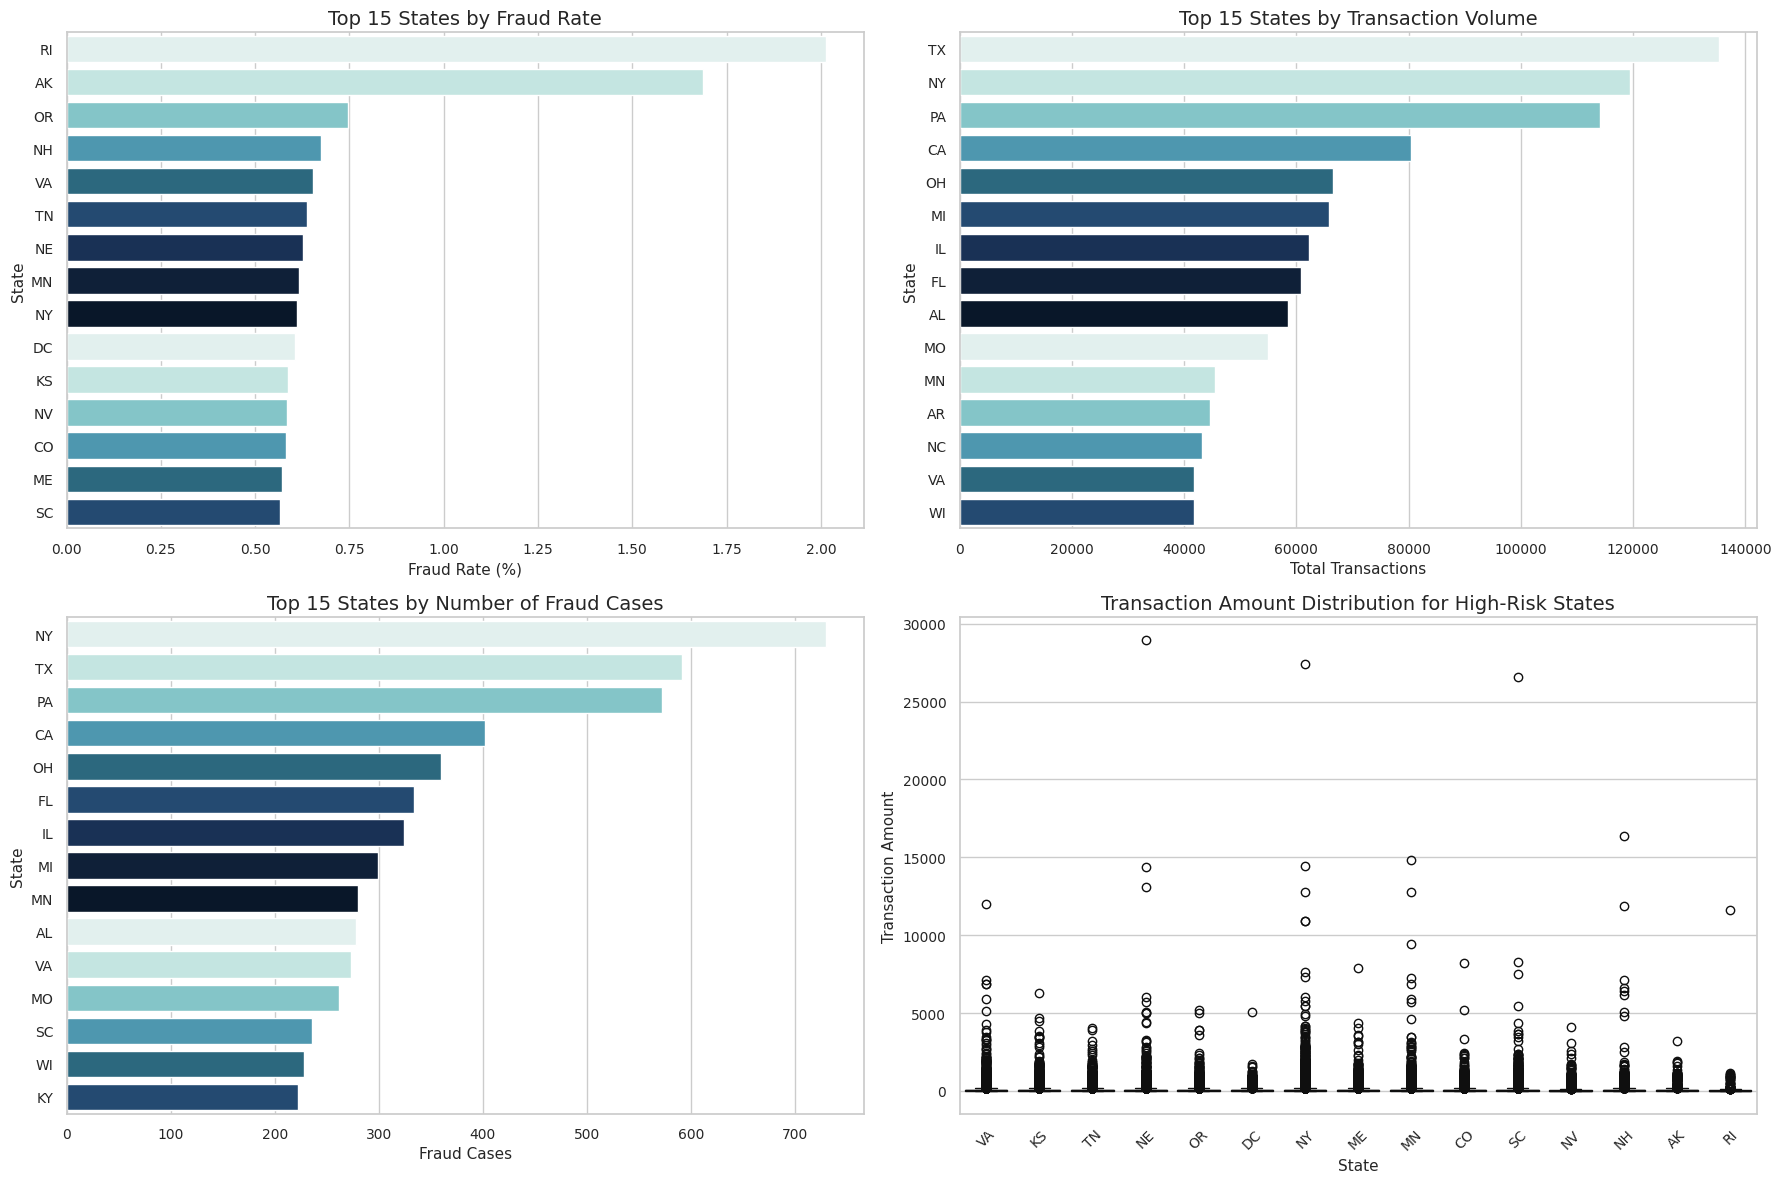

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=top_states,
    x="fraud_rate_pct",
    y="state",
    palette=OCEAN_PALETTE[:len(top_states)],
    ax=axes[0, 0]
)
axes[0, 0].set_title("Top 15 States by Fraud Rate")
axes[0, 0].set_xlabel("Fraud Rate (%)")
axes[0, 0].set_ylabel("State")

sns.barplot(
    data=top_volume_states,
    x="total_transactions",
    y="state",
    palette=OCEAN_PALETTE[:len(top_volume_states)],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Top 15 States by Transaction Volume")
axes[0, 1].set_xlabel("Total Transactions")
axes[0, 1].set_ylabel("State")

sns.barplot(
    data=top_fraud_count_states,
    x="fraud_cases",
    y="state",
    palette=OCEAN_PALETTE[:len(top_fraud_count_states)],
    ax=axes[1, 0]
)
axes[1, 0].set_title("Top 15 States by Number of Fraud Cases")
axes[1, 0].set_xlabel("Fraud Cases")
axes[1, 0].set_ylabel("State")

top_states_list = top_states["state"].tolist()

sns.boxplot(
    data=df_state[df_state["state"].isin(top_states_list)],
    x="state",
    y="amt",
    palette=OCEAN_PALETTE[:len(top_states_list)],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Transaction Amount Distribution for High-Risk States")
axes[1, 1].set_xlabel("State")
axes[1, 1].set_ylabel("Transaction Amount")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## 15. City-Level Analysis

City-level analysis gives a more local view of transaction concentration and fraud exposure.

In [27]:
city_summary = (
    df.groupby("city")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

city_summary["fraud_rate_pct"] = city_summary["fraud_rate"] * 100

min_city_count = 100

top20_cities_fraud_rate = (
    city_summary[city_summary["count"] >= min_city_count]
    .sort_values(["fraud_rate_pct", "count"], ascending=[False, False])
    .head(20)
)

top20_cities_fraud_cases = (
    city_summary[city_summary["count"] >= min_city_count]
    .sort_values(["fraud_cases", "count"], ascending=[False, False])
    .head(20)
)

top20_cities_volume = (
    city_summary.sort_values("count", ascending=False)
    .head(20)
)

print("Top 20 Cities by Fraud Rate (Minimum Support Applied)")
display(top20_cities_fraud_rate)

print("Top 20 Cities by Fraud Cases (Minimum Support Applied)")
display(top20_cities_fraud_cases)

print("Top 20 Cities by Transaction Volume")
display(top20_cities_volume)

Top 20 Cities by Fraud Rate (Minimum Support Applied)


,city,count,fraud_cases,fraud_rate,fraud_rate_pct
153,Clearwater,753,24,0.0319,3.1873
40,Aurora,750,23,0.0307,3.0667
67,Benton,750,20,0.0267,2.6667
137,Chatham,743,16,0.0215,2.1534
388,Jay,743,16,0.0215,2.1534
539,Moscow,745,16,0.0215,2.1477
702,Riverview,741,15,0.0202,2.0243
84,Boulder,743,15,0.0202,2.0188
288,Girard,743,15,0.0202,2.0188
365,Howes Cave,743,15,0.0202,2.0188


Top 20 Cities by Fraud Cases (Minimum Support Applied)


,city,count,fraud_cases,fraud_rate,fraud_rate_pct
362,Houston,5865,39,0.0066,0.6650
194,Dallas,5141,39,0.0076,0.7586
74,Birmingham,8040,36,0.0045,0.4478
571,New York City,3680,35,0.0095,0.9511
11,Allentown,5119,34,0.0066,0.6642
118,Camden,3678,34,0.0092,0.9244
848,Warren,6584,33,0.0050,0.5012
213,Detroit,5124,33,0.0064,0.6440
850,Washington,5130,31,0.0060,0.6043
26,Arcadia,5850,30,0.0051,0.5128


Top 20 Cities by Transaction Volume


,city,count,fraud_cases,fraud_rate,fraud_rate_pct
74,Birmingham,8040,36,0.0045,0.4478
733,San Antonio,7312,25,0.0034,0.3419
832,Utica,7309,25,0.0034,0.3420
651,Phoenix,7297,17,0.0023,0.2330
507,Meridian,7289,18,0.0025,0.2469
848,Warren,6584,33,0.0050,0.5012
171,Conway,6574,17,0.0026,0.2586
154,Cleveland,6572,18,0.0027,0.2739
807,Thomas,6571,23,0.0035,0.3500
362,Houston,5865,39,0.0066,0.6650


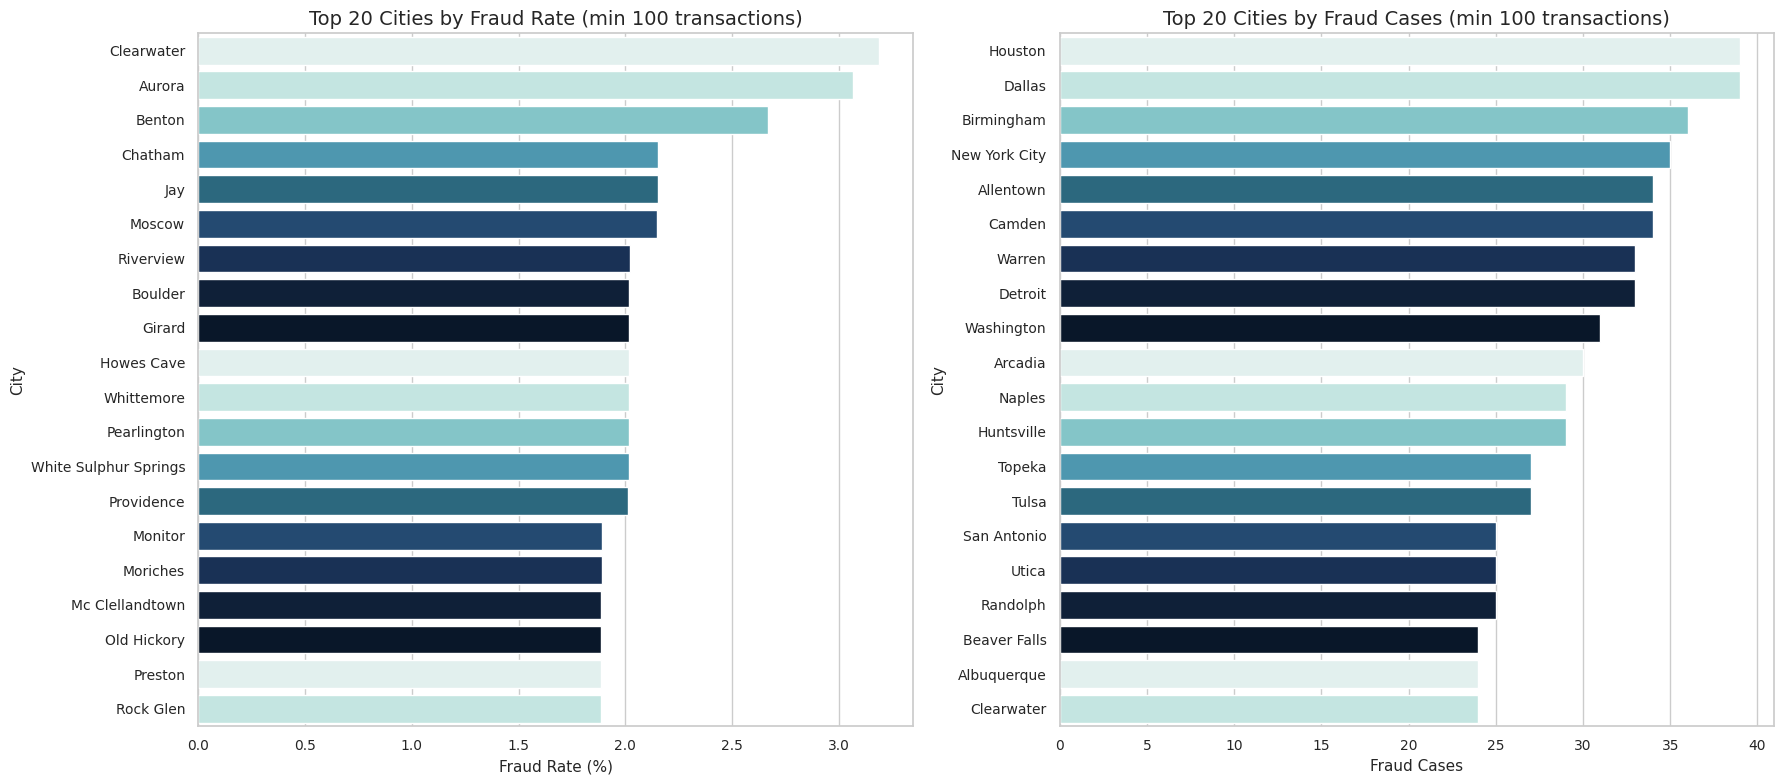

In [28]:
min_city_count = 100

top20_cities_fraud_rate = (
    city_summary[city_summary["count"] >= min_city_count]
    .sort_values(["fraud_rate_pct", "count"], ascending=[False, False])
    .head(20)
)

top20_cities_fraud_cases = (
    city_summary[city_summary["count"] >= min_city_count]
    .sort_values(["fraud_cases", "count"], ascending=[False, False])
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Fraud Rate
sns.barplot(
    data=top20_cities_fraud_rate,
    y="city",
    x="fraud_rate_pct",
    palette=OCEAN_PALETTE[:len(top20_cities_fraud_rate)],
    ax=axes[0]
)
axes[0].set_title(f"Top 20 Cities by Fraud Rate (min {min_city_count} transactions)")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].set_ylabel("City")

# Fraud Cases
sns.barplot(
    data=top20_cities_fraud_cases,
    y="city",
    x="fraud_cases",
    palette=OCEAN_PALETTE[:len(top20_cities_fraud_cases)],
    ax=axes[1]
)
axes[1].set_title(f"Top 20 Cities by Fraud Cases (min {min_city_count} transactions)")
axes[1].set_xlabel("Fraud Cases")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

---
## 16. City Population Analysis

City population is used here as a proxy for transaction environment.

In [29]:
df["city_pop_band"] = pd.qcut(
    df["city_pop"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

city_pop_summary = (
    df.groupby("city_pop_band", observed=False)["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

city_pop_summary["fraud_rate_pct"] = city_pop_summary["fraud_rate"] * 100
display(city_pop_summary)

,city_pop_band,count,fraud_cases,fraud_rate,fraud_rate_pct
0,Very Low,370964,1848,0.0050,0.4982
1,Low,370236,1847,0.0050,0.4989
2,Medium,371155,2013,0.0054,0.5424
3,High,370438,2060,0.0056,0.5561
4,Very High,369601,1883,0.0051,0.5095


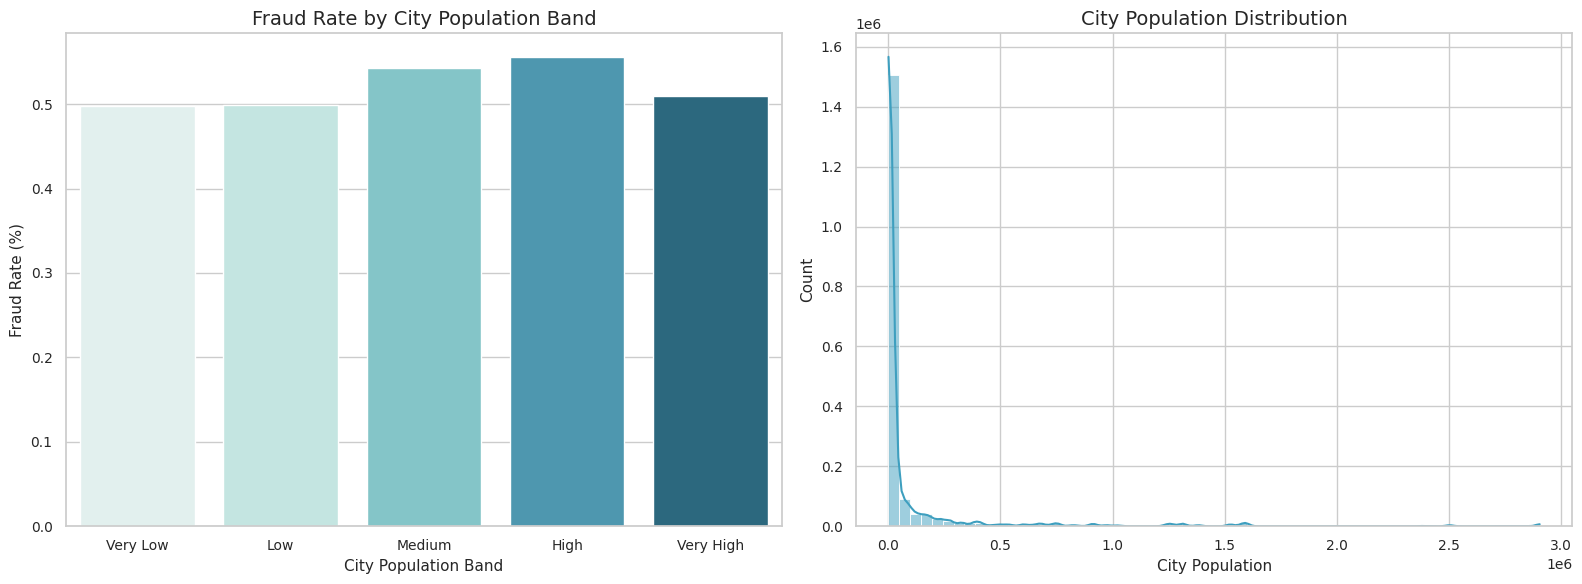

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=city_pop_summary,
    x="city_pop_band",
    y="fraud_rate_pct",
    palette=OCEAN_PALETTE[:len(city_pop_summary)],
    ax=axes[0]
)
axes[0].set_title("Fraud Rate by City Population Band")
axes[0].set_xlabel("City Population Band")
axes[0].set_ylabel("Fraud Rate (%)")

sns.histplot(
    df["city_pop"],
    bins=60,
    kde=True,
    color=OCEAN_PALETTE[3],
    ax=axes[1]
)
axes[1].set_title("City Population Distribution")
axes[1].set_xlabel("City Population")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## 17. Merchant Category Analysis

Category is one of the most important transaction context variables because fraud risk often differs across transaction types.

In [31]:
category_counts = df["category"].value_counts()

category_summary = (
    df.groupby("category", observed=False)["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

category_summary["fraud_rate_pct"] = category_summary["fraud_rate"] * 100
category_summary_sorted = category_summary.sort_values("fraud_rate_pct", ascending=False)

display(category_summary_sorted)

,category,count,fraud_cases,fraud_rate,fraud_rate_pct
11,shopping_net,139322,2219,0.0159,1.5927
8,misc_net,90654,1182,0.0130,1.3039
4,grocery_pos,176191,2228,0.0126,1.2645
12,shopping_pos,166463,1056,0.0063,0.6344
2,gas_transport,188029,772,0.0041,0.4106
9,misc_pos,114229,322,0.0028,0.2819
3,grocery_net,64878,175,0.0027,0.2697
13,travel,57956,156,0.0027,0.2692
10,personal_care,130085,290,0.0022,0.2229
0,entertainment,134118,292,0.0022,0.2177


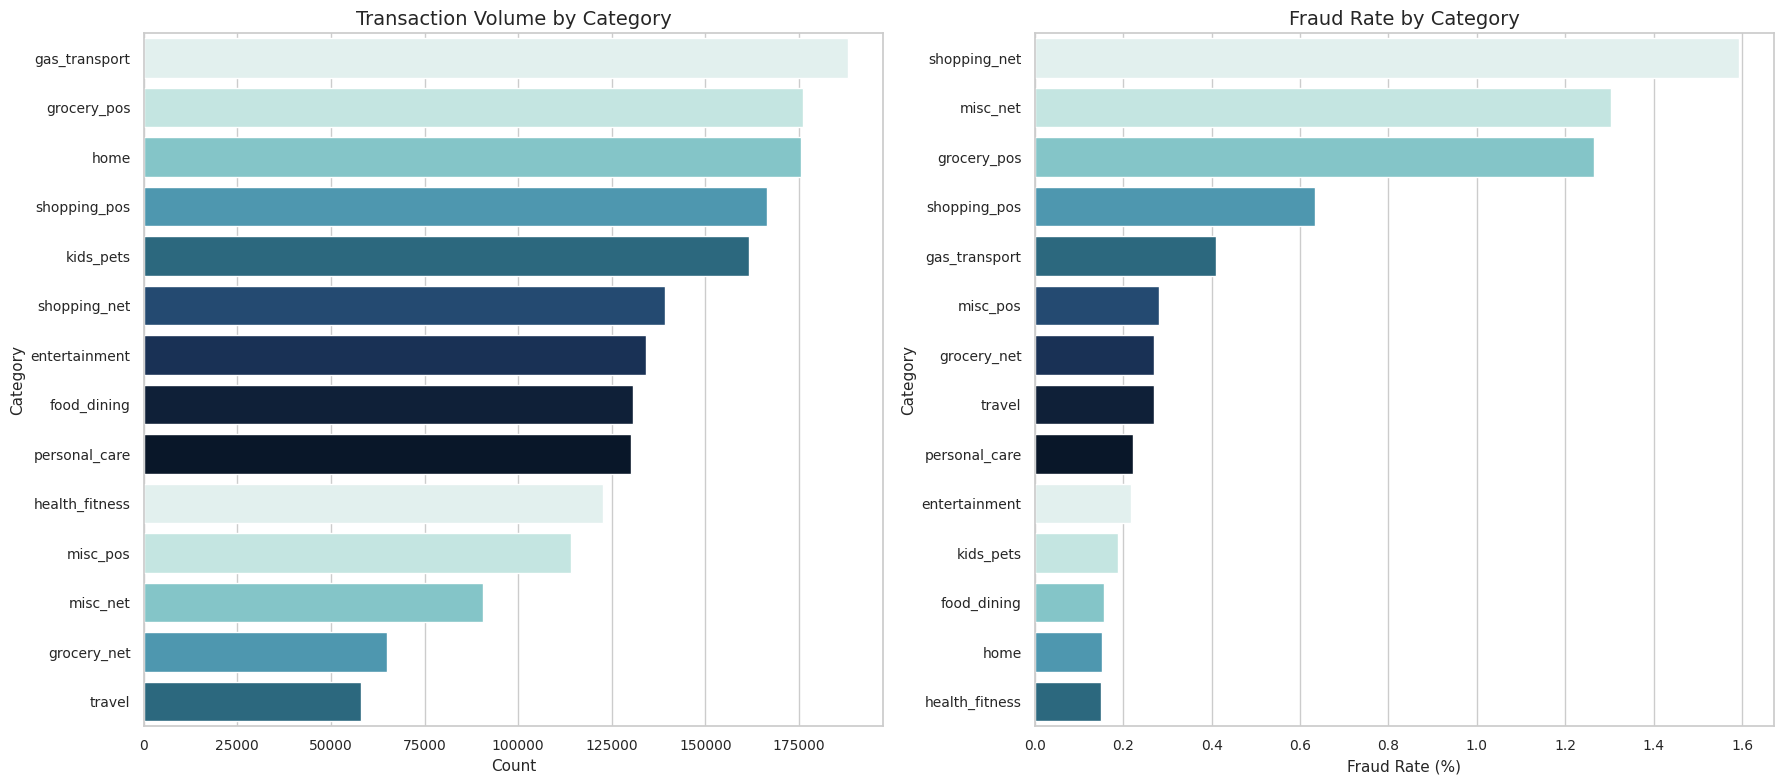

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    y=category_counts.index,
    x=category_counts.values,
    palette=OCEAN_PALETTE[:len(category_counts)],
    ax=axes[0]
)
axes[0].set_title("Transaction Volume by Category")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

sns.barplot(
    data=category_summary_sorted,
    y="category",
    x="fraud_rate_pct",
    palette=OCEAN_PALETTE[:len(category_summary_sorted)],
    ax=axes[1]
)
axes[1].set_title("Fraud Rate by Category")
axes[1].set_xlabel("Fraud Rate (%)")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

---
## 18. Merchant Analysis

Merchant-level behavior helps identify whether fraud is concentrated around particular transaction endpoints.

In [33]:
merchant_summary = (
    df.groupby("merchant")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

merchant_summary["fraud_rate_pct"] = merchant_summary["fraud_rate"] * 100

top_merchants = merchant_summary.sort_values("count", ascending=False).head(15)
display(top_merchants)

,merchant,count,fraud_cases,fraud_rate,fraud_rate_pct
316,fraud_Kilback LLC,6262,62,0.0099,0.9901
105,fraud_Cormier LLC,5246,53,0.0101,1.0103
571,fraud_Schumm PLC,5195,41,0.0079,0.7892
349,fraud_Kuhn LLC,5031,55,0.0109,1.0932
70,fraud_Boyer PLC,4999,55,0.0110,1.1002
136,fraud_Dickinson Ltd,4953,9,0.0018,0.1817
157,fraud_Emard Inc,3867,13,0.0034,0.3362
117,fraud_Cummerata-Jones,3860,19,0.0049,0.4922
107,fraud_Corwin-Collins,3853,15,0.0039,0.3893
522,fraud_Rodriguez Group,3843,15,0.0039,0.3903


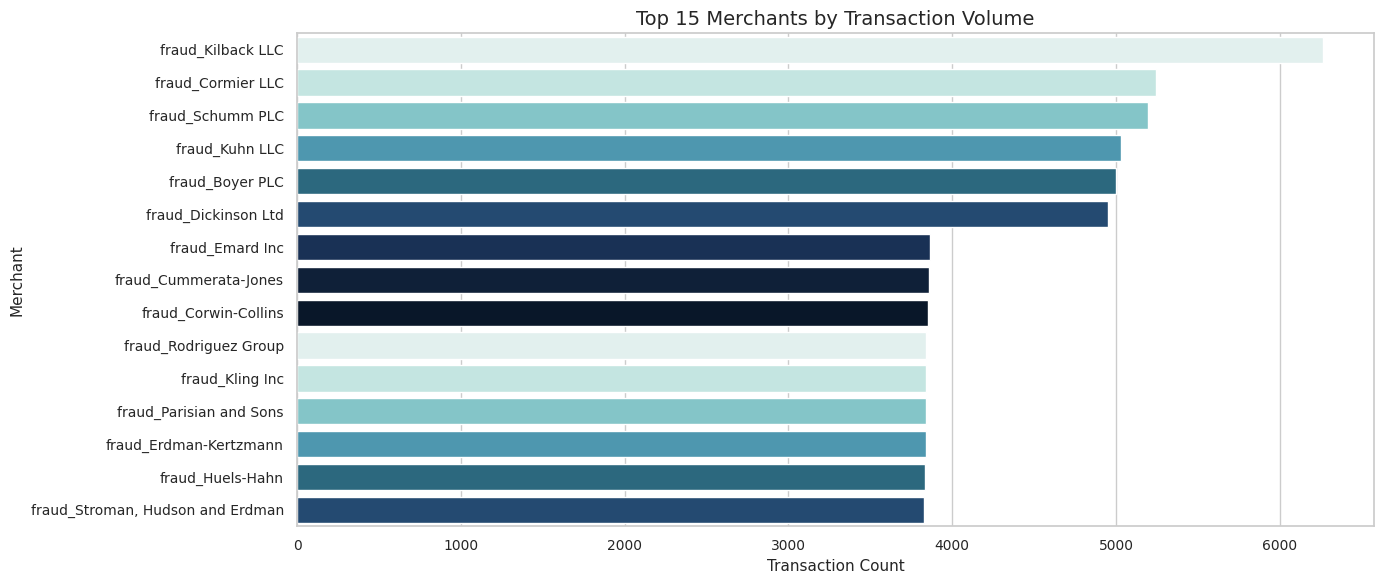

In [34]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=top_merchants,
    y="merchant",
    x="count",
    palette=OCEAN_PALETTE[:len(top_merchants)]
)
plt.title("Top 15 Merchants by Transaction Volume")
plt.xlabel("Transaction Count")
plt.ylabel("Merchant")
plt.tight_layout()
plt.show()

---
## 19. Occupation Analysis

Occupation is examined as a descriptive demographic context variable.

In [35]:
job_summary = (
    df.groupby("job")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

job_summary["fraud_rate_pct"] = job_summary["fraud_rate"] * 100

# Minimum support
min_job_count = 100

job_summary_filtered = (
    job_summary[job_summary["count"] >= min_job_count]
    .sort_values(["fraud_rate_pct", "count"], ascending=[False, False])
)

# Show ALL jobs (not top 15)
display(job_summary_filtered)

,job,count,fraud_cases,fraud_rate,fraud_rate_pct
448,TEFL teacher,760,32,0.0421,4.2105
263,Lawyer,757,28,0.0370,3.6988
98,Community development worker,751,22,0.0293,2.9294
2,"Accountant, chartered certified",751,21,0.0280,2.7963
229,Horticultural consultant,746,19,0.0255,2.5469
...,...,...,...,...,...
219,Health physicist,4374,3,0.0007,0.0686
107,Contractor,4366,2,0.0005,0.0458
163,"Engineer, drilling",2920,0,0.0000,0.0000
161,"Engineer, communications",2190,0,0.0000,0.0000


In [36]:
job_summary = (
    df.groupby("job")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)

job_summary["fraud_rate_pct"] = job_summary["fraud_rate"] * 100

min_job_count = 100

# Top 20 by Fraud Rate (filtered)
top20_jobs_fraud_rate = (
    job_summary[job_summary["count"] >= min_job_count]
    .sort_values(["fraud_rate_pct", "count"], ascending=[False, False])
    .head(20)
)

# Top 20 by Fraud Cases (filtered)
top20_jobs_fraud_cases = (
    job_summary[job_summary["count"] >= min_job_count]
    .sort_values(["fraud_cases", "count"], ascending=[False, False])
    .head(20)
)

# Top 20 by Volume (no filter needed)
top20_jobs_volume = (
    job_summary.sort_values("count", ascending=False)
    .head(20)
)

print("Top 20 Jobs by Fraud Rate (Min Support)")
display(top20_jobs_fraud_rate)

print("Top 20 Jobs by Fraud Cases (Min Support)")
display(top20_jobs_fraud_cases)

print("Top 20 Jobs by Transaction Volume")
display(top20_jobs_volume)

Top 20 Jobs by Fraud Rate (Min Support)


,job,count,fraud_cases,fraud_rate,fraud_rate_pct
448,TEFL teacher,760,32,0.0421,4.2105
263,Lawyer,757,28,0.0370,3.6988
98,Community development worker,751,22,0.0293,2.9294
2,"Accountant, chartered certified",751,21,0.0280,2.7963
229,Horticultural consultant,746,19,0.0255,2.5469
88,Clinical cytogeneticist,744,18,0.0242,2.4194
308,Nature conservation officer,743,16,0.0215,2.1534
211,"Geneticist, molecular",745,16,0.0215,2.1477
496,Writer,741,15,0.0202,2.0243
105,"Conservator, museum/gallery",743,15,0.0202,2.0188


Top 20 Jobs by Fraud Cases (Min Support)


,job,count,fraud_cases,fraud_rate,fraud_rate_pct
383,Quantity surveyor,8080,69,0.0085,0.8540
309,Naval architect,12434,66,0.0053,0.5308
287,Materials engineer,11711,62,0.0053,0.5294
42,Audiological scientist,8801,58,0.0066,0.6590
421,Senior tax professional/tax inspector,5877,57,0.0097,0.9699
480,Trading standards officer,6611,56,0.0085,0.8471
346,Podiatrist,9525,54,0.0057,0.5669
194,Film/video editor,13898,52,0.0037,0.3742
188,Exhibition designer,13167,51,0.0039,0.3873
92,Colour technologist,5146,51,0.0099,0.9911


Top 20 Jobs by Transaction Volume


,job,count,fraud_cases,fraud_rate,fraud_rate_pct
194,Film/video editor,13898,52,0.0037,0.3742
188,Exhibition designer,13167,51,0.0039,0.3873
442,"Surveyor, land/geomatics",12436,50,0.0040,0.4021
309,Naval architect,12434,66,0.0053,0.5308
287,Materials engineer,11711,62,0.0053,0.5294
121,"Designer, ceramics/pottery",11688,23,0.0020,0.1968
179,Environmental consultant,10974,37,0.0034,0.3372
195,Financial adviser,10963,42,0.0038,0.3831
447,Systems developer,10962,42,0.0038,0.3831
240,IT trainer,10943,37,0.0034,0.3381


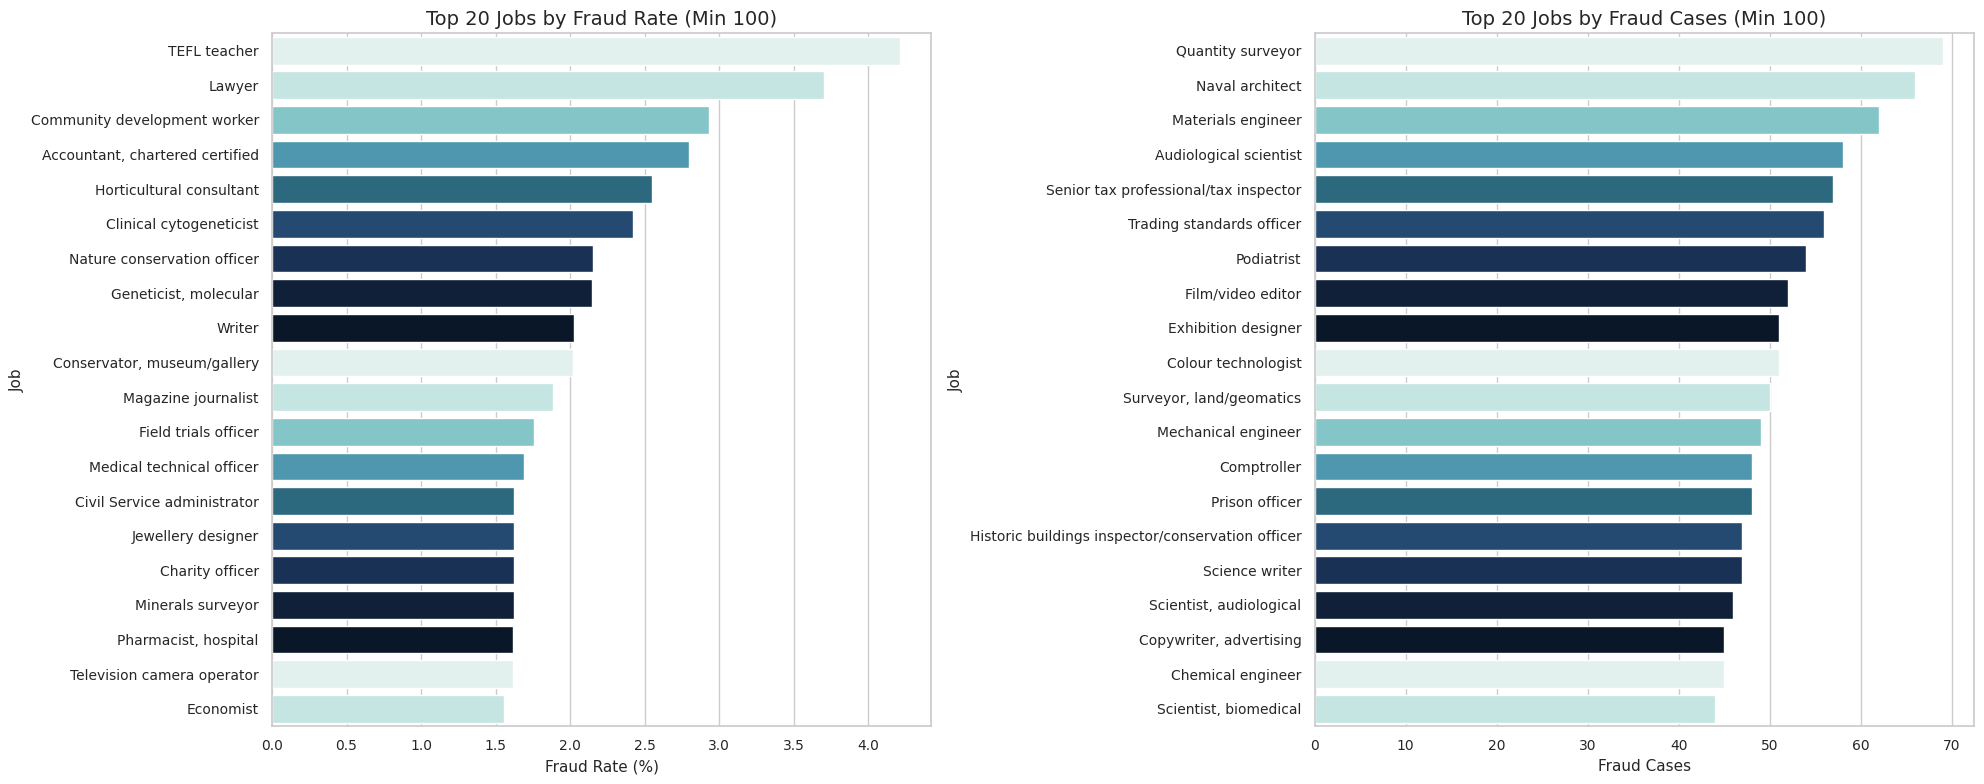

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(
    data=top20_jobs_fraud_rate,
    y="job",
    x="fraud_rate_pct",
    palette=OCEAN_PALETTE[:len(top20_jobs_fraud_rate)],
    ax=axes[0]
)
axes[0].set_title(f"Top 20 Jobs by Fraud Rate (Min {min_job_count})")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].set_ylabel("Job")

sns.barplot(
    data=top20_jobs_fraud_cases,
    y="job",
    x="fraud_cases",
    palette=OCEAN_PALETTE[:len(top20_jobs_fraud_cases)],
    ax=axes[1]
)
axes[1].set_title(f"Top 20 Jobs by Fraud Cases (Min {min_job_count})")
axes[1].set_xlabel("Fraud Cases")
axes[1].set_ylabel("Job")

plt.tight_layout()
plt.show()

---
## 20. Fraud vs Legitimate Transaction Amount

This section compares amount behavior between fraud and non-fraud transactions.

In [38]:
display(df.groupby("is_fraud")["amt"].describe())

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,"1,842,743.0000",67.6513,153.5481,1.0000,9.6100,47.2400,82.5600,"28,948.9000"
1,"9,651.0000",530.6614,391.0289,1.0600,240.0750,390.0000,902.3650,"1,376.0400"


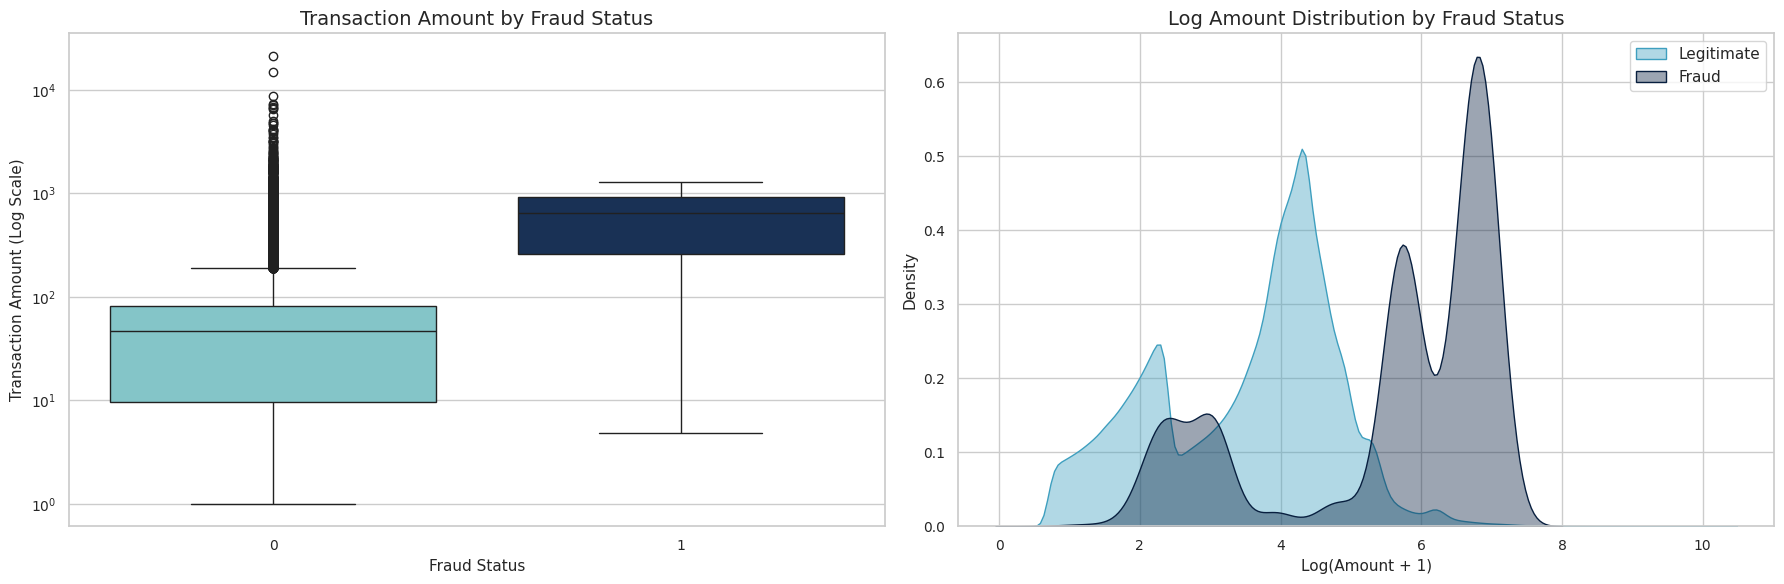

In [39]:
sample_df = df.sample(min(100000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=sample_df,
    x="is_fraud",
    y="amt",
    palette=[OCEAN_PALETTE[2], OCEAN_PALETTE[6]],
    ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set_title("Transaction Amount by Fraud Status")
axes[0].set_xlabel("Fraud Status")
axes[0].set_ylabel("Transaction Amount (Log Scale)")

sns.kdeplot(
    data=df[df["is_fraud"] == 0],
    x="log_amt",
    fill=True,
    alpha=0.4,
    color=OCEAN_PALETTE[3],
    label="Legitimate",
    ax=axes[1]
)
sns.kdeplot(
    data=df[df["is_fraud"] == 1],
    x="log_amt",
    fill=True,
    alpha=0.4,
    color=OCEAN_PALETTE[7],
    label="Fraud",
    ax=axes[1]
)
axes[1].set_title("Log Amount Distribution by Fraud Status")
axes[1].set_xlabel("Log(Amount + 1)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 21. Temporal Fraud Pattern Analysis

Fraud behavior often has strong temporal structure. This section examines fraud across:

- hour of day
- day of week
- month
- night versus day

In [40]:
hour_summary = (
    df.groupby("trans_hour")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)
hour_summary["fraud_rate_pct"] = hour_summary["fraud_rate"] * 100

dow_summary = (
    df.groupby("trans_day_name")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)
dow_summary["fraud_rate_pct"] = dow_summary["fraud_rate"] * 100

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary["trans_day_name"] = pd.Categorical(dow_summary["trans_day_name"], categories=day_order, ordered=True)
dow_summary = dow_summary.sort_values("trans_day_name")

month_summary = (
    df.groupby("trans_month")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)
month_summary["fraud_rate_pct"] = month_summary["fraud_rate"] * 100

night_summary = (
    df.groupby("is_night_transaction")["is_fraud"]
      .agg(count="count", fraud_cases="sum", fraud_rate="mean")
      .reset_index()
)
night_summary["fraud_rate_pct"] = night_summary["fraud_rate"] * 100

display(hour_summary.head())
display(dow_summary)
display(month_summary)
display(night_summary)

,trans_hour,count,fraud_cases,fraud_rate,fraud_rate_pct
0,0,60655,823,0.0136,1.3569
1,1,61330,827,0.0135,1.3484
2,2,60796,793,0.0130,1.3044
3,3,60968,803,0.0132,1.3171
4,4,59938,61,0.0010,0.1018


,trans_day_name,count,fraud_cases,fraud_rate,fraud_rate_pct
1,Monday,369418,1484,0.0040,0.4017
5,Tuesday,270340,1266,0.0047,0.4683
6,Wednesday,183913,1125,0.0061,0.6117
4,Thursday,206741,1317,0.0064,0.6370
0,Friday,215078,1376,0.0064,0.6398
2,Saturday,263227,1493,0.0057,0.5672
3,Sunday,343677,1590,0.0046,0.4626


,trans_month,count,fraud_cases,fraud_rate,fraud_rate_pct
0,1,104727,849,0.0081,0.8107
1,2,97657,853,0.0087,0.8735
2,3,143789,938,0.0065,0.6523
3,4,134970,678,0.0050,0.5023
4,5,146875,935,0.0064,0.6366
5,6,173869,821,0.0047,0.4722
6,7,172444,652,0.0038,0.3781
7,8,176118,797,0.0045,0.4525
8,9,140185,758,0.0054,0.5407
9,10,138106,838,0.0061,0.6068


,is_night_transaction,count,fraud_cases,fraud_rate,fraud_rate_pct
0,0,1417373,1482,0.0010,0.1046
1,1,435021,8169,0.0188,1.8778


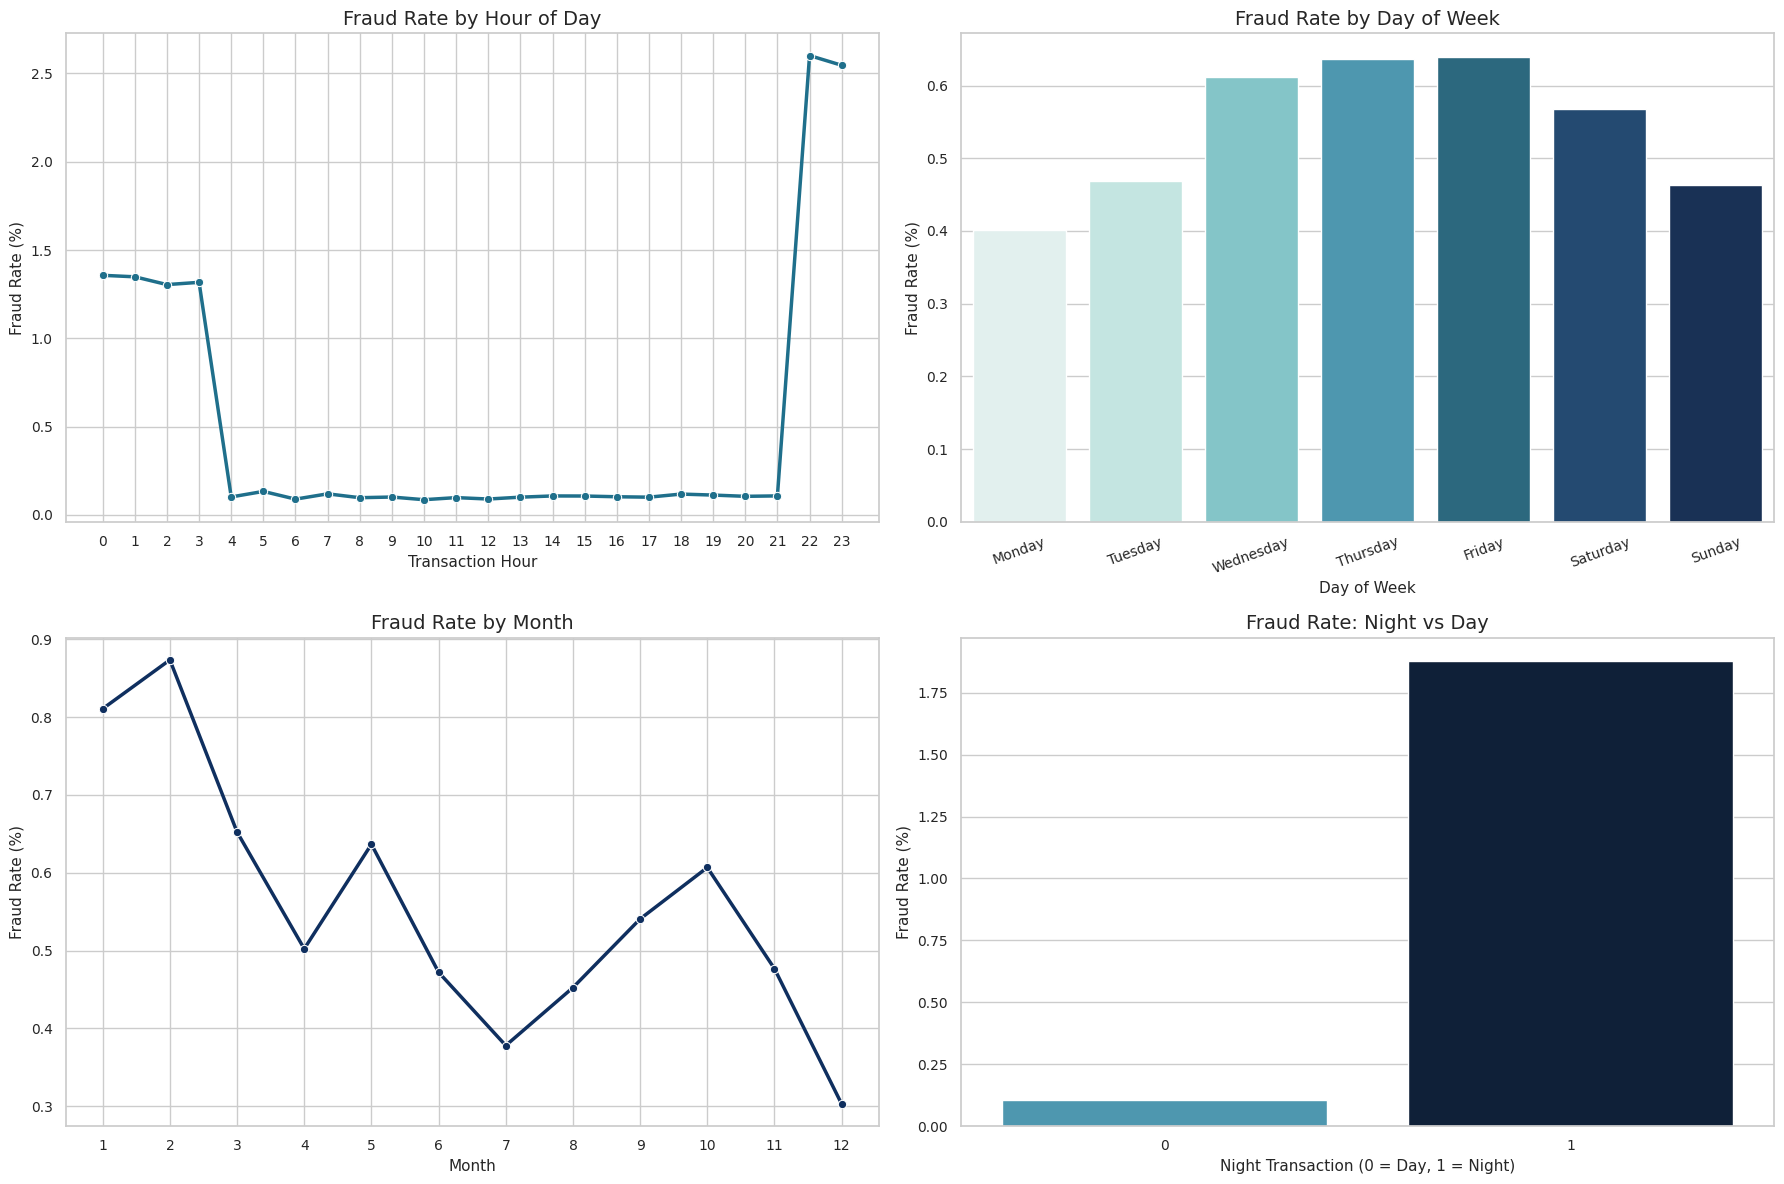

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(
    data=hour_summary,
    x="trans_hour",
    y="fraud_rate_pct",
    marker="o",
    color=OCEAN_PALETTE[4],
    linewidth=2.5,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Fraud Rate by Hour of Day")
axes[0, 0].set_xlabel("Transaction Hour")
axes[0, 0].set_ylabel("Fraud Rate (%)")
axes[0, 0].set_xticks(range(0, 24))

sns.barplot(
    data=dow_summary,
    x="trans_day_name",
    y="fraud_rate_pct",
    palette=OCEAN_PALETTE[:8],
    ax=axes[0, 1]
)
axes[0, 1].set_title("Fraud Rate by Day of Week")
axes[0, 1].set_xlabel("Day of Week")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.lineplot(
    data=month_summary,
    x="trans_month",
    y="fraud_rate_pct",
    marker="o",
    color=OCEAN_PALETTE[6],
    linewidth=2.5,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Fraud Rate by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Fraud Rate (%)")
axes[1, 0].set_xticks(range(1, 13))

sns.barplot(
    data=night_summary,
    x="is_night_transaction",
    y="fraud_rate_pct",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[7]],
    ax=axes[1, 1]
)
axes[1, 1].set_title("Fraud Rate: Night vs Day")
axes[1, 1].set_xlabel("Night Transaction (0 = Day, 1 = Night)")
axes[1, 1].set_ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

---
## 22. Geographic Pattern Analysis

The dataset includes both customer and merchant coordinates. These can be used to understand whether transactions appear spatially clustered.

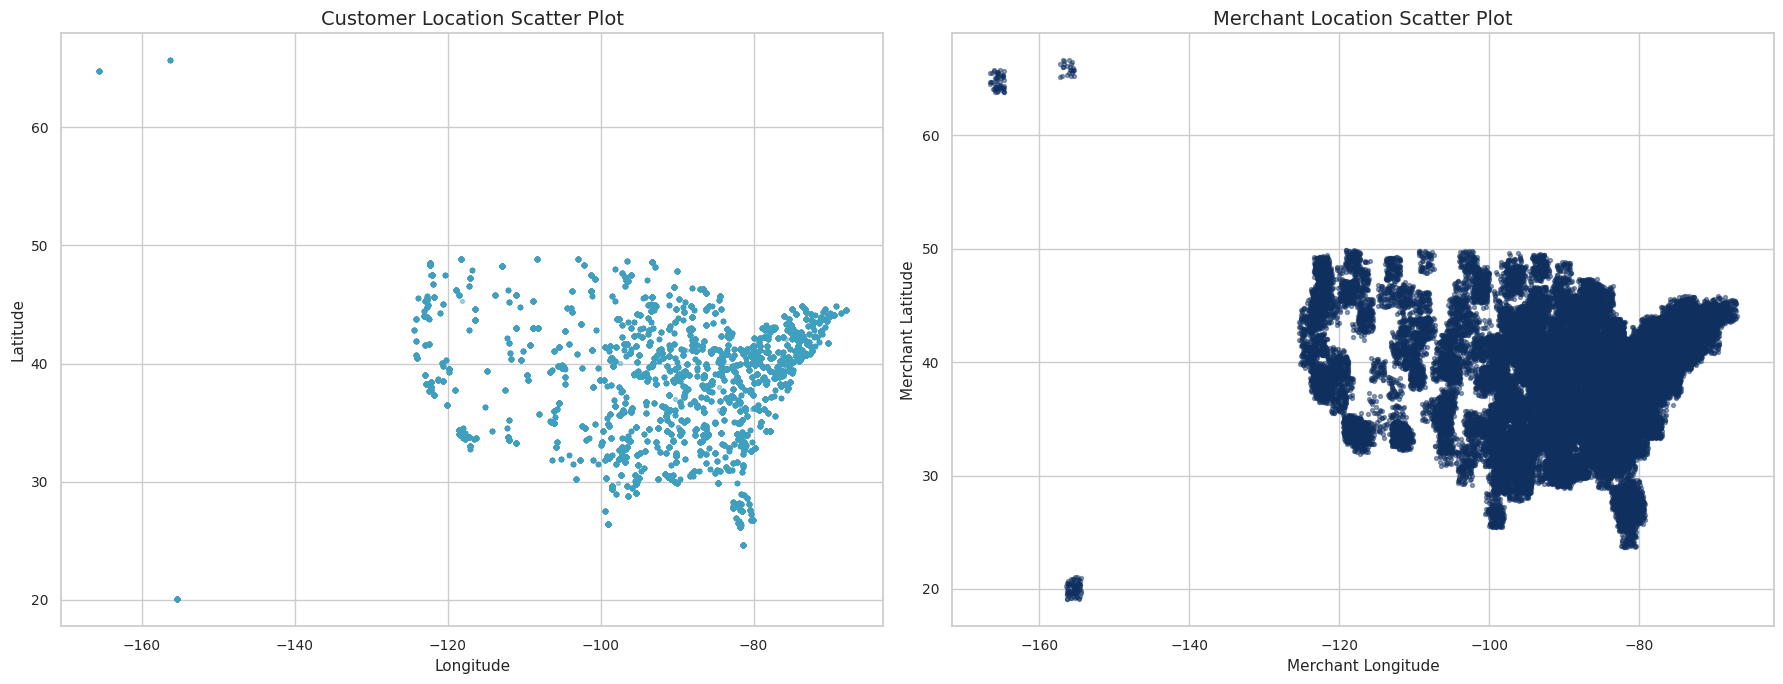

In [42]:
sample_geo = df.sample(min(50000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(
    sample_geo["long"],
    sample_geo["lat"],
    s=8,
    alpha=0.45,
    color=OCEAN_PALETTE[3]
)
axes[0].set_title("Customer Location Scatter Plot")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

axes[1].scatter(
    sample_geo["merch_long"],
    sample_geo["merch_lat"],
    s=8,
    alpha=0.45,
    color=OCEAN_PALETTE[6]
)
axes[1].set_title("Merchant Location Scatter Plot")
axes[1].set_xlabel("Merchant Longitude")
axes[1].set_ylabel("Merchant Latitude")

plt.tight_layout()
plt.show()

#### Insight

Geographic concentration may reflect regional customer patterns, merchant density, or transaction routing structures. While location alone is not enough to identify fraud, it adds important context when combined with amount, merchant, and timing information.

---
## 23. Category and Gender Interaction

This section checks whether fraud patterns vary across categories within gender groups.

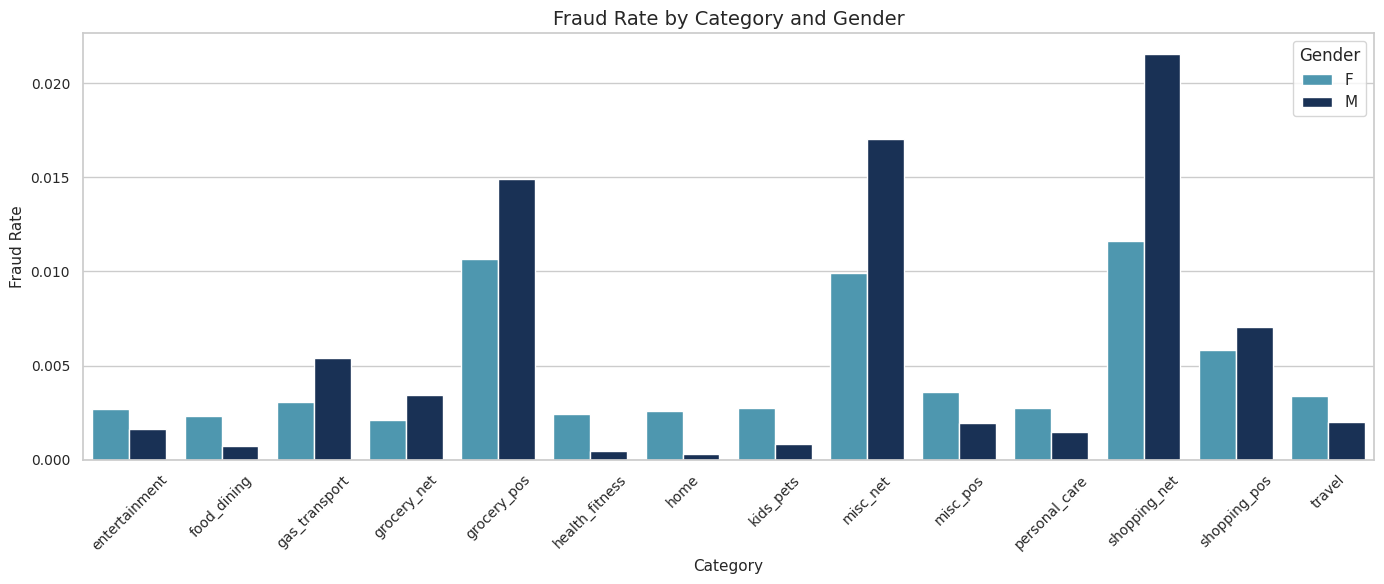

In [43]:
gender_category_fraud = (
    df.groupby(["gender", "category"])["is_fraud"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=gender_category_fraud,
    x="category",
    y="is_fraud",
    hue="gender",
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[6]]
)
plt.title("Fraud Rate by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

---
## 24. Amount and Age Relationship

This section examines whether transaction size and age interact differently across fraud and non-fraud observations.

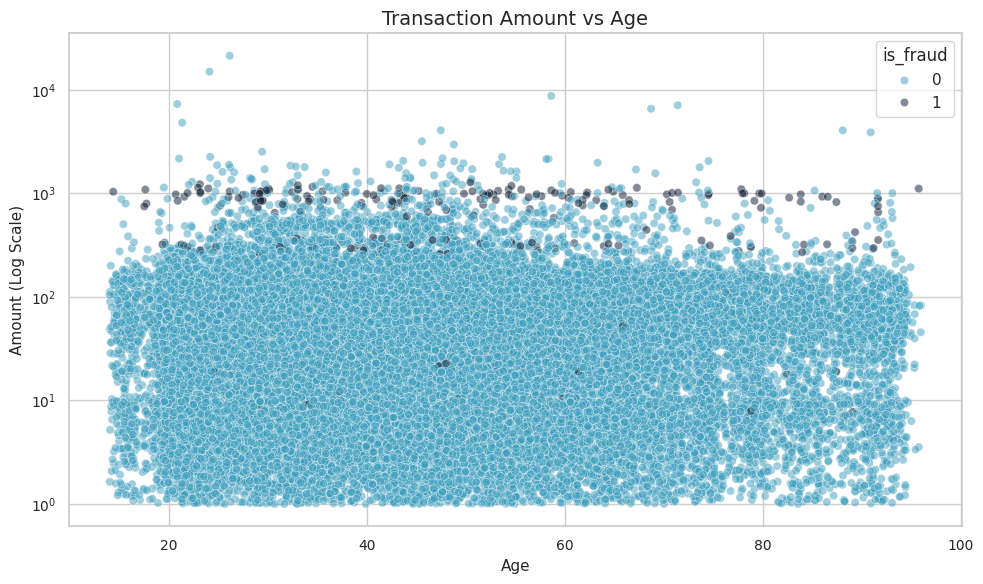

In [44]:
sample_scatter = df.sample(min(50000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_scatter,
    x="age",
    y="amt",
    hue="is_fraud",
    alpha=0.5,
    palette=[OCEAN_PALETTE[3], OCEAN_PALETTE[8]]
)
plt.yscale("log")
plt.title("Transaction Amount vs Age")
plt.xlabel("Age")
plt.ylabel("Amount (Log Scale)")
plt.legend(title="is_fraud")
plt.tight_layout()
plt.show()

---
## 25. Top Fraud Concentration Tables

This section consolidates fraud concentration across major grouping dimensions.

In [45]:
top_state_fraud_table = state_summary.sort_values("fraud_rate_pct", ascending=False).head(15)
top_city_fraud_table = city_summary.sort_values("fraud_rate_pct", ascending=False).head(15)
top_category_fraud_table = category_summary.sort_values("fraud_rate_pct", ascending=False).head(15)
top_merchant_fraud_table = merchant_summary.sort_values("fraud_rate_pct", ascending=False).head(15)

print("Top 15 States by Fraud Rate")
display(top_state_fraud_table)

print("Top 15 Cities by Fraud Rate")
display(top_city_fraud_table)

print("Top 15 Categories by Fraud Rate")
display(top_category_fraud_table)

print("Top 15 Merchants by Fraud Rate")
display(top_merchant_fraud_table)

Top 15 States by Fraud Rate


,state,total_transactions,fraud_cases,fraud_rate,fraud_rate_pct
38,RI,745,15,0.0201,2.0134
0,AK,2963,50,0.0169,1.6875
36,OR,26408,197,0.0075,0.7460
29,NH,11727,79,0.0067,0.6737
44,VA,41756,273,0.0065,0.6538
41,TN,24913,159,0.0064,0.6382
28,NE,34425,216,0.0063,0.6275
22,MN,45433,280,0.0062,0.6163
33,NY,119419,730,0.0061,0.6113
7,DC,5130,31,0.0060,0.6043


Top 15 Cities by Fraud Rate


,city,count,fraud_cases,fraud_rate,fraud_rate_pct
446,Lexington,11,11,1.0000,100.0000
473,Madisonville,11,11,1.0000,100.0000
35,Ashland,10,10,1.0000,100.0000
57,Beacon,11,11,1.0000,100.0000
423,La Grande,12,12,1.0000,100.0000
455,Lockhart,9,9,1.0000,100.0000
417,Kirtland,10,10,1.0000,100.0000
416,Kirkwood,12,12,1.0000,100.0000
647,Phelps,11,11,1.0000,100.0000
438,Las Vegas,8,8,1.0000,100.0000


Top 15 Categories by Fraud Rate


,category,count,fraud_cases,fraud_rate,fraud_rate_pct
11,shopping_net,139322,2219,0.0159,1.5927
8,misc_net,90654,1182,0.0130,1.3039
4,grocery_pos,176191,2228,0.0126,1.2645
12,shopping_pos,166463,1056,0.0063,0.6344
2,gas_transport,188029,772,0.0041,0.4106
9,misc_pos,114229,322,0.0028,0.2819
3,grocery_net,64878,175,0.0027,0.2697
13,travel,57956,156,0.0027,0.2692
10,personal_care,130085,290,0.0022,0.2229
0,entertainment,134118,292,0.0022,0.2177


Top 15 Merchants by Fraud Rate


,merchant,count,fraud_cases,fraud_rate,fraud_rate_pct
337,fraud_Kozey-Boehm,2758,60,0.0218,2.1755
245,"fraud_Herman, Treutel and Dickens",1870,38,0.0203,2.0321
616,fraud_Terry-Huel,2864,56,0.0196,1.9553
304,fraud_Kerluke-Abshire,2635,50,0.0190,1.8975
443,"fraud_Mosciski, Ziemann and Farrell",2821,53,0.0188,1.8788
555,"fraud_Schmeler, Bashirian and Price",2788,52,0.0187,1.8651
346,fraud_Kuhic LLC,2842,53,0.0186,1.8649
282,fraud_Jast Ltd,2757,51,0.0185,1.8498
372,"fraud_Langworth, Boehm and Gulgowski",2817,52,0.0185,1.8459
528,"fraud_Romaguera, Cruickshank and Greenholt",2767,51,0.0184,1.8432


---
## 26. Correlation Analysis

Correlation analysis provides a limited but useful view of linear relationships among selected numerical features.

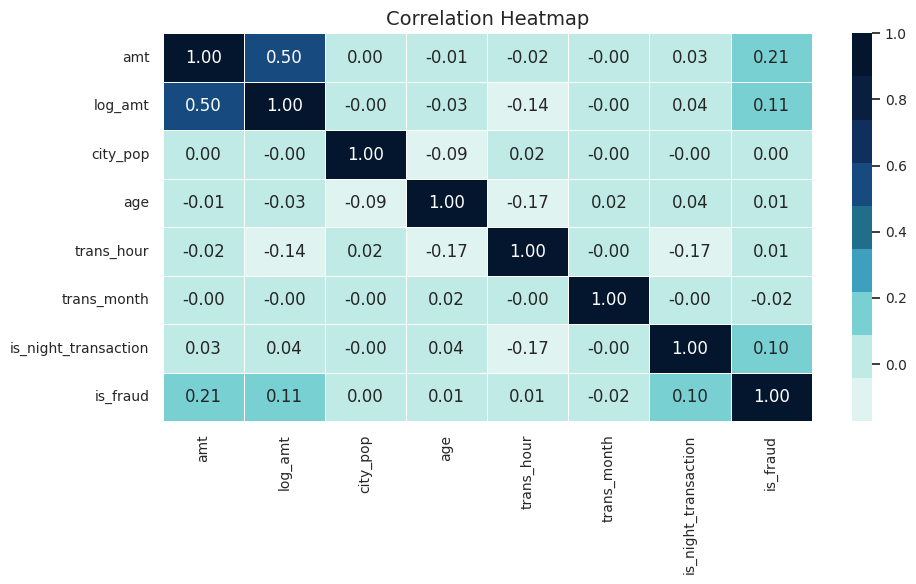

In [46]:
corr_cols = [
    "amt",
    "log_amt",
    "city_pop",
    "age",
    "trans_hour",
    "trans_month",
    "is_night_transaction",
    "is_fraud"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(OCEAN_PALETTE, as_cmap=True),
    linewidths=0.5,
    cbar=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

---
# Key Fraud Insights

### 1. Extreme Class Imbalance
- Fraudulent transactions account for approximately **0.5%** of all transactions, while legitimate transactions dominate at **~99.5%**.
- This confirms a **highly imbalanced classification problem**, where:
  - Accuracy is misleading
  - Models must prioritize **recall, precision, and PR-AUC**
- Even a small improvement in fraud detection can have **significant real-world impact**.

---

### 2. Transaction Amount Drives Fraud Risk
- Transaction amounts are **heavily right-skewed**, with most transactions being small and a few extremely large outliers.
- Fraudulent transactions tend to occur at **higher transaction values**, clearly visible in:
  - Boxplots (fraud distribution shifted upward)
  - KDE plots (fraud concentrated at higher log values)
- Log transformation significantly improves:
  - Distribution symmetry
  - Model usability
- **Amount is one of the strongest predictors of fraud**.

---

### 3. Temporal Fraud Patterns

#### Hour of Day
- Fraud rates are:
  - **Stable and low during daytime hours**
  - **Extremely high during late-night hours (around 22:00–23:00)**
- Night transactions show a **massive spike in fraud risk**.

#### Night vs Day
- Night transactions have **significantly higher fraud rates** compared to daytime transactions.
- This validates the importance of the **`is_night_transaction` feature**.

#### Day of Week
- Fraud increases during:
  - **Midweek (Wednesday–Friday)**
- Lower fraud rates observed:
  - **Start and end of the week**

#### Month
- Fraud shows **seasonal variation**, with:
  - Higher fraud early in the year
  - Gradual decline toward year-end
- Indicates possible **temporal fraud cycles**

---

### 4. Demographic Risk Patterns

#### Age
- Most transactions occur between **25–55 years**.
- Fraud risk:
  - **Lowest in younger groups (25–44)**
  - **Highest in older groups (55+)**
- Fraud rate increases **with age**, especially after 50.

#### Gender
- Females generate **more transactions overall**.
- Males have a **higher fraud rate**.
- This indicates **behavioral differences in fraud exposure**, not just volume differences.

---

### 5. Geographic Concentration of Fraud

#### State-Level Insights
- High fraud volumes are concentrated in large states such as:
  - **Texas, New York, Pennsylvania, California**
- Some smaller states exhibit **higher fraud rates**, despite lower volume.
- This highlights:
  - **Fraud rate ≠ transaction volume**
  - Both must be modeled separately.

#### City-Level Insights
- Fraud is concentrated in specific cities with sufficient transaction volume.
- High-risk cities emerge when filtering for **minimum transaction thresholds**.
- Indicates **localized fraud hotspots** rather than uniform distribution.

#### Population Effect
- Fraud rate slightly increases with **city population size**.
- Medium-to-high population bands show **elevated fraud risk**.
- Suggests fraud thrives in **denser, more active environments**.

---

### 6. Category-Based Fraud Behavior
- Fraud risk varies significantly by transaction category.

#### High-Risk Categories
- `shopping_net` (highest fraud rate)
- `misc_net`
- `grocery_pos`

#### Moderate Risk
- `shopping_pos`
- `gas_transport`

#### Low-Risk Categories
- `food_dining`
- `home`
- `health_fitness`

- Online-related categories consistently show **higher fraud exposure**, reinforcing:
  - Risk in **card-not-present transactions**

---

### 7. Merchant-Level Risk Patterns
- Certain merchants (especially synthetic or flagged ones like `fraud_*`) dominate transaction counts.
- This suggests:
  - Presence of **fraud-heavy merchant clusters**
  - Potential for **merchant-level risk encoding**
- Merchant identity is a **highly predictive categorical feature**.

---

### 8. Spatial Clustering (Customer vs Merchant)
- Customer and merchant locations show **strong geographic clustering**.
- Fraud appears concentrated in **specific regions**, not random.
- Suggests value in:
  - **Distance-based features**
  - **Location mismatch detection**

---

### 9. Feature Relationships (Correlation Analysis)
- Most features show **low linear correlation with fraud**, indicating:
  - Fraud is **non-linear and interaction-driven**
- Notable relationships:
  - `amt` → moderate correlation with fraud (~0.21)
  - `log_amt` → smaller but meaningful correlation (~0.11)
  - `is_night_transaction` → positive relationship with fraud
- Weak correlations confirm:
  - Need for **advanced models and feature engineering**

---

### 10. Behavior is More Important Than Raw Data
- Fraud is not explained by single variables alone.
- It emerges from:
  - **Interactions (time + amount + category)**
  - **Context (location + user profile)**
- Strong signals exist, but only when **features are combined properly**.

---

# Final Conclusion

This analysis shows that fraud detection is a **highly complex, imbalanced, and behavior-driven problem**.

Key conclusions:

- Fraud is **rare but structured**, not random.
- The most important drivers of fraud include:
  - **Transaction amount**
  - **Time (especially night activity)**
  - **Transaction category (online vs offline)**
  - **Geographic location**
  - **Customer demographics (age, gender)**
- Fraud is strongly influenced by **behavioral context**, rather than isolated features.

From a modeling perspective:

- Traditional approaches relying on raw variables will underperform.
- Effective fraud detection requires:
  - **Feature engineering (temporal, behavioral, spatial)**
  - **Handling class imbalance**
  - **Non-linear models (tree-based, ensemble methods)**

Strategic direction for next stages:

- Build **behavior-driven features**, including:
  - Night indicators
  - Category risk encodings
  - Geographic risk features
  - Transaction patterns over time
- Use **robust evaluation metrics**:
  - Precision, Recall, F1-score, PR-AUC
- Implement models capable of capturing **complex interactions**

Overall, this dataset contains **strong fraud signals**, but they are embedded within:
- Imbalance
- Noise
- Non-linear relationships

The success of the project will depend on **how well these hidden patterns are extracted and modeled**.

In [47]:
final_profile_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Fraud Cases",
        "Fraud Rate (%)",
        "Unique Customers",
        "Unique Merchants",
        "Unique Categories",
        "Unique States",
        "Unique Cities"
    ],
    "Value": [
        len(df),
        int(df["is_fraud"].sum()),
        round(df["is_fraud"].mean() * 100, 4),
        df["cc_num"].nunique() if "cc_num" in df.columns else np.nan,
        df["merchant"].nunique(),
        df["category"].nunique(),
        df["state"].nunique(),
        df["city"].nunique()
    ]
})

display(final_profile_summary)

,Metric,Value
0,Total Transactions,"1,852,394.0000"
1,Total Fraud Cases,"9,651.0000"
2,Fraud Rate (%),0.5210
3,Unique Customers,999.0000
4,Unique Merchants,693.0000
5,Unique Categories,14.0000
6,Unique States,51.0000
7,Unique Cities,906.0000
